# SETUP

In [ ]:
import copy
import math
import gc
import glob
import logging
import multiprocessing
import operator
import os
import subprocess
import itertools
import tempfile
import time

import numpy as np
import pandas as pd
from tqdm import tqdm
from subprocess import Popen, PIPE

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import EnumerateStereoisomers
from rdkit.Chem import MolStandardize
from rdkit.Chem import rdDistGeom
from rdkit.Chem import rdMolAlign
from rdkit.ML.Cluster import Butina
from rdkit.Chem import DataStructs

OBABEL_PATH = "/chemotargets/shared/conda/envs/obabel/bin/obabel"
def obabel_protonate(mol, ph=7):
    """
    WARNING: DO NO NOT DISTRIBUTE THIS CODE.
    OpenBabel is under GPL license.
    DO NOT LINK DIRECTLY TO OBABEL LIBS

    NOT AVAILABLE IN RDKIT: USE BABEL EXECUTABLE
    Importing pybel and rdkit at the same time produces impredictive behaviour

    """

    cmd = [OBABEL_PATH, "-i mol", "-o mol"]

    if ph:
        cmd.append("-p {}".format(ph))

    p = Popen(" ".join(cmd), stdout=PIPE, stdin=PIPE, stderr=PIPE, shell=True)
    stdout, stderr = p.communicate(input=mol.encode('utf-8'))
    mol2 = stdout.decode('utf-8')
    return mol2


class Molecule(object):
    """
    Extends RDkit Mol class by composition """

    def __init__(self, mol=None):

        self._molecule = mol
        self.properties = {}

        if mol is not None:
            assert isinstance(mol, Chem.Mol)

        self.lines = None
        self._infile = None


    def __getattr__(self, attr):
        # Allows the class to be pickable avoiding RecursionError
        if attr == "molecule":
            raise AttributeError

        if attr == "_molecule":
            raise AttributeError

        return getattr(self.molecule, attr)

    def __setitem__(self, key, value):
        self.properties[key] = value
        if self.molecule is not None:
            self.molecule.SetProp(key, str(value))

    def __getitem__(self, key):
        try:
            return self.properties[key]
        except KeyError:
            return self.molecule.GetProp(key)

    def __delitem__(self, key):
        self.properties.remove(key)

    def __contains__(self, key):
        return key in self.properties

    def __str__(self):
        smiles = "NOT LOADED"
        if self.molecule:
            smiles = Chem.MolToSmiles(self.molecule)
        return "{} {}".format(self.__class__, smiles)

    @property
    def molecule(self):
        return self._molecule

    @molecule.setter
    def molecule(self, value):
        if value is not None:
            assert isinstance(value, Chem.rdchem.Mol)
        self._molecule = value

    @property
    def infile(self):
        return self._infile

    @infile.setter
    def infile(self, value):
        if value is not None:
            self._infile = value

    def get_molecule(self):
        return self.molecule

    def append(self, molecule):
        try:
            self.molecules.append(molecule)
        except AttributeError:
            self.molecules = [molecule]

    def get_properties(self):
        return self.properties

    def set_property(self, name, value):
        if name == "_Name":
            self.name = value
        self.properties[name] = value

    def keys(self):
        return self.properties.keys()

    def clear_properties(self):
        self.properties = {}
        for property in self.molecule.GetPropNames(includePrivate=True):
            self.molecule.ClearProp(property)

    def fix_charges(self):
        """
        Tries to fix unssigned charges
        Needs to have read the molecule with sanitize=False


        Based on:
        https://www.blopig.com/blog/2024/09/out-of-the-box-rdkit-valid-is-an-imperfect-metric-a-review-of-the-kekulizeexception-and-nitrogen-protonation-to-correct-this/
        """

        self.molecule.UpdatePropertyCache(strict=False)
        problems = Chem.DetectChemistryProblems(self.molecule)

        for problem in problems:

            if problem.GetType() =='AtomValenceException':

                atom = self.molecule.GetAtomWithIdx(problem.GetAtomIdx())

                if atom.GetAtomicNum() == 7 and atom.GetFormalCharge() == 0 and atom.GetExplicitValence() == 4:
                    atom.SetFormalCharge(1)

                if atom.GetAtomicNum() == 8 and atom.GetFormalCharge() == 0 and atom.GetExplicitValence() == 3:
                    atom.SetFormalCharge(1)

        Chem.SanitizeMol(self.molecule)

    def generate_conformers(self, n: int = 1,
                            rms: float = 0.5,
                            ref: bool = False,
                            seed: int = -1,
                            compute_energies: bool = False,
                            pH: int = 7,
                            fast: bool = False):
        """
        Generate conformers for the molecule.

        Args:
            n (int): Number of conformers to generate.
            rms (float): RMS threshold for conformer pruning.
            ref (bool): Flag indicating whether to add a reference conformer.
            seed (int): Random seed for conformer generation.
            compute_energies (bool): Flag indicating whether to compute conformer energies.
            fast (int): If true does NOT optimize conformer energies.

        Returns:
            conformers (list): List[Molecule] of generated conformers.
        """

        mol = self.molecule

        # Protonate
        if pH is not None:
            mol = Molecule(self.protonate(pH)).molecule

        # Adding Explicit Hydrogens
        mol = Chem.AddHs(mol, addCoords=True)
        refmol = Chem.AddHs(Chem.Mol(mol))

        # Generate conformers using RDKit
        param = rdDistGeom.ETKDGv2()
        param.randomSeed = seed
        param.pruneRmsThresh = rms
        param.maxAttempts = 500
        param.enforceChirality = True
        cids = rdDistGeom.EmbedMultipleConfs(mol=mol, numConfs=n, params=param)

        # No conformers coud be generated
        if len(cids) == 0:
            return []

        # Energy Optimization of each conformer
        if not fast:

            mp = AllChem.MMFFGetMoleculeProperties(mol, mmffVariant="MMFF94s")
            AllChem.MMFFOptimizeMoleculeConfs(mol, numThreads=1, mmffVariant='MMFF94s')
            rdMolAlign.AlignMolConformers(mol)

            # Prunning conformers after energy minimization

            selected = [cids[0]]
            for i, cid in enumerate(cids[1:]):
                j = i+1
                min_rmsd = []
                while j < len(cids):
                    # maxMatches kept low to keep running time reasonable.
                    bestrmsd = AllChem.GetBestRMS(mol, mol,  cids[i], cids[j], maxMatches=1000)
                    min_rmsd.append(bestrmsd)
                    j += 1
                    if bestrmsd < rms:
                        break
                if min(min_rmsd) > rms:
                    selected.append(cid)

            cids = selected

        # Split conformers in molecules

        conformers = []

        if ref:
            # Add reference conformer
            refmol.SetProp("_Name", self.name if self.name else "")
            refmol.SetProp("CID", "-1")
            refmol.SetProp("Energy", "")
            conformers.append(Molecule(refmol))

        if compute_energies:

            # Calculate energies sequentially
            energy = {}
            for cid in cids:
                e = self.calculate_energy(mol, mp, cid)
                energy[cid] = e

            sorted_cids = sorted(energy, key=energy.get)

            # Add conformers with energies
            for cid in sorted_cids:
                m = Chem.Mol(refmol, True)
                m.AddConformer(mol.GetConformer(cid))
                m = Molecule(m)
                m.set_properties(self.get_properties())
                m.name = self.name if self.name else ""
                m["CID"] = str(cid)
                m["Energy"] = str(energy[cid])
                conformers.append(m)
        else:
            # Add conformers without energies
            for cid in cids:
                m = Chem.Mol(refmol, True)
                m.AddConformer(mol.GetConformer(cid))
                m = Molecule(m)
                m.set_properties(self.get_properties())
                m.name = self.name if self.name else ""
                m["CID"] = str(cid)
                m.set_properties()
                conformers.append(m)

        return conformers

    def calculate_energy(self, mol, mp, cid):
        """
        Calculate the energy of a conformer using MMFF force field.

        Args:
            mol (Molecule): The molecule object.
            mp: The molecule properties object.
            cid (int): Conformer ID.

        Returns:
            energy (float): The calculated energy.
        """
        ff = AllChem.MMFFGetMoleculeForceField(mol, mp, confId=cid)
        return ff.CalcEnergy()



    def get_conformer(self, nconf=0):
        return self.GetConformer(nconf)

    def cluster_conformers(self, threshold=0.5, prune=False):

        dmat = AllChem.GetConformerRMSMatrix(self.molecule, prealigned=False)
        clusters = Butina.ClusterData(dmat, self.molecule.GetNumConformers(), threshold, isDistData=True, reordering=True)

        if not prune:
            return clusters

        else:
            cid = [x[0] for x in clusters]
            m = Chem.Mol(self.molecule, True)
            m.SetProp("_Name", self.name)

            for conformer in self.GetConformers():
                if conformer.GetId() not in cid:
                    continue
                m.AddConformer(conformer, assignId=True)

        return m


    @property
    def name(self):
        try:
            return self["_Name"]
        except KeyError:
            return

    @name.setter
    def name(self, name):
        self["_Name"] = name

    def set_properties(self, properties=None):

        if properties:
            self.properties = copy.deepcopy(properties)

        # Set properties
        self.properties.update({k: self.molecule.GetProp(k) for
                                k in self.molecule.GetPropNames(includePrivate=True) if
                                k not in self.properties})

        # Set name
        try:
            self.properties["_Name"] = self.molecule.GetProp("_Name")
        except KeyError:
            pass

        for key, value in self.properties.items():
            if key not in self.molecule.GetPropNames(includePrivate=True):
                self.molecule.SetProp(key,  str(value))
    def get_atom_fpt(self, niter=8):

        fpt = {}
        for atom in self.GetAtoms():
            fpt[atom.GetIdx()] = self.get_atom_fpt_by_atom(atom, niter=niter)

        return fpt

    def get_atom_fpt_by_atom(self, atom, niter=8):

        seen = set([atom.GetIdx()])
        current = [atom.GetIdx()]
        fpt = []

        for i in range(niter):

            fpt.append("".join(sorted([self.GetAtomWithIdx(x).GetSymbol() for x in current])))

            seen.update(current)

            current = [self.GetAtomWithIdx(x).GetNeighbors() for x in current]
            current = set([a.GetIdx() for neigh in current for a in neigh if a.GetIdx() not in seen])

        return ".".join([x for x in fpt if x])

    def get_substructure_rms(self, molecule, mcs=None):

        if mcs is None:
            mcs = rdFMCS.FindMCS([self.molecule, molecule.molecule], completeRingsOnly=True)
        pattern = Chem.MolFromSmarts(mcs.smartsString)

        a = Molecule(self.get_fragment_by_pattern(pattern))
        b = Molecule(molecule.get_fragment_by_pattern(pattern))

        rmsd = a.rmsd(b)
        return rmsd

    def get_fragment_by_pattern(self, pattern):

        core = Chem.ReplaceSidechains(self.molecule, pattern)

        for b in core.GetBonds():
            if b.GetBeginAtom().GetAtomicNum() == 0 and b.GetEndAtom().GetAtomicNum() == 0:
                core = Chem.RWMol(core)
                core.RemoveBond(b.GetBeginAtom().GetIdx(), b.GetEndAtom().GetIdx())
            elif b.GetBeginAtom().GetAtomicNum() == 0 or b.GetEndAtom().GetAtomicNum() == 0:
                b.SetBondType(Chem.BondType.SINGLE)
                b.SetIsAromatic(False)

        for a in core.GetAtoms():
            if (not a.IsInRing()):
                a.SetIsAromatic(False)
            if a.GetAtomicNum() == 0:
                a.SetAtomicNum(1)
                a.SetIsotope(0)
                a.SetIsAromatic(False)

        core = Chem.RemoveHs(core)

        return core

    def rmsd(self, reference, returnMatch=False):

        rmsd = Chem.rdMolAlign.CalcRMS(self.molecule,
                                       reference.molecule,
                                       symmetrizeConjugatedTerminalGroups=True)

        # Try uncharging the molecule
        if not rmsd:

            one = self.uncharge()
            other = reference.uncharge()

            rmsd = Chem.rdMolAlign.CalcRMS(one.molecule, other.molecule,
                                           symmetrizeConjugatedTerminalGroups=True)

        return rmsd

    def rmsd_advanced(self, reference, rdkit=True, returnMatch=False, max_tries=1000000):

        if rdkit:
            mapping = self.get_atom_mapping_rdkit(reference)
        else:
            mapping = self.get_atom_mapping_fingerprints(reference, max_tries=max_tries)

        rmsd, mappingBest = self.get_rmsd_for_mapping(reference, mapping)

        if returnMatch:
            return rmsd, mappingBest

        return rmsd

    def get_rmsd_for_mapping(self, reference, mapping):

        if not mapping:
            return None, None

        RMS = []
        for match in mapping:
            rms = 0
            for i, atom in enumerate(reference.GetAtoms()):

                pos1 = self.molecule.GetConformer(0).GetAtomPosition(match[atom.GetIdx()])
                pos2 = reference.GetConformer(0).GetAtomPosition(atom.GetIdx())

                p1 = np.array([pos1.x, pos1.y, pos1.z])
                p2 = np.array([pos2.x, pos2.y, pos2.z])

                rms += np.sum((p1-p2) ** 2)

            rms = math.sqrt(rms/reference.GetNumAtoms())
            RMS.append(rms)

        return min(RMS), mapping[np.argmin(np.array(RMS))]
    def get_atom_mapping_rdkit(self, reference):
        """
        Get atom mapping between two molecules using rdkit substructure matching
        """

        try:

            matches = self.molecule.GetSubstructMatches(reference.molecule,
                                                        uniquify=False,
                                                        useChirality=False,
                                                        useQueryQueryMatches=True)
        except Exception:
            return

        # Try uncharging the molecule
        if not matches:
            one = self.uncharge()
            other = reference.uncharge()
            try:
                matches = one.molecule.GetSubstructMatches(other.molecule,
                                                           uniquify=False,
                                                           useChirality=False,
                                                           useQueryQueryMatches=True)
            except Exception:
                return


        return matches

    def get_atom_mapping_fingerprints(self, reference, max_tries=1000000):

        fptref = self.get_atom_fpt(niter=8)
        fpt = reference.get_atom_fpt(niter=8)

        pairs = []
        for atom in self.GetAtoms():
            idx = atom.GetIdx()
            pairs.append([x for x in fptref if fptref[x] == fpt[idx]])

        matches = []
        for i, match in enumerate(itertools.product(*pairs)):

            if i > max_tries:
                break

            if len(set(match)) == len(match):
                matches.append(match)

        return matches

    def enumerate_tautomers(self, score=False, sort:bool=False):
        """ Enumerate tautomers """

        enumerator = MolStandardize.rdMolStandardize.TautomerEnumerator()
        tautomers = [Molecule(m) for m in enumerator.Enumerate(self.molecule)]
        [m.set_properties() for m in tautomers]

        if score:

            for tautomer in tautomers:
                score = enumerator.ScoreTautomer(tautomer.molecule)
                tautomer["tautomer_score"] = score

            tautomers.sort(key=lambda mol: float(mol["tautomer_score"]), reverse=True)

        return tautomers

    def enumerate_stereoisomers(self):


        Chem.FindMolChiralCenters(self.molecule, includeUnassigned=True)

        options = EnumerateStereoisomers.StereoEnumerationOptions(unique=False)
        isomers = [Molecule(m) for m in EnumerateStereoisomers.EnumerateStereoisomers(self.molecule, options=options)]

        # Setting parent properties
        [m.set_properties(self.get_properties()) for m in isomers]
        return isomers

    def count_charged_atoms(self) -> int:
        """
        Counts the number of charged atoms in a molecule.
        """
        return sum([1 for at in self.GetAtoms() if at.GetFormalCharge() != 0])

    def check_protonation(self):
        """
        Check for unrealistic overprotonation """

        # Number of charged atoms <= 3
        if self.count_charged_atoms() > 3:
            return False

        # Net Charge [-1, 0, 1]
        if Chem.GetFormalCharge(self.molecule) not in [-1, 0, 1]:
            return False

        return True

    def protonate(self, ph: int = 7):

        mol = obabel_protonate(Chem.MolToMolBlock(self.molecule), ph=ph)
        m = Chem.MolFromMolBlock(mol, sanitize=True)

        # Openbabel tends to overprotonate.
        # Discard compounds with multiple charges

        if m is None or Molecule(m).check_protonation() is False:
            return self.molecule
        return m



class Molecules:
    """
    Manages a list of molecules (Molecule) """

    def __init__(self, infile=None, molecules=None, name=None, read=False,
                 rdkit=True, removeHs=True, sanitize=True,
                 format="sdf", **kwargs):

        self.name = name
        self.molecules = molecules
        self.infile = infile
        self.sanitize = sanitize
        self.removeHs = removeHs
        self.format = format
        config =  {
            "smiles_separator": "\t",
            "smiles_header": True,
            "format_file_extensions": {
                "sdf": [".sdf", ".sd"],
                "smi": [".smi", ".smiles"]}}

        self.config = copy.deepcopy(config)
        self.rdkit = rdkit

        self.config.update(kwargs)

        self.size = None
        self.modified = False

        self.index = None
        self._iter = None

        # Convert rdkit.Chem to Molecule
        if molecules is not None:
            self.molecules = [Molecule(x) if isinstance(x, Chem.Mol)
                              else x for x in molecules]

        if read:
            self.load()

        self.operators = {
            "==": operator.eq,
            "<": operator.lt,
            "<=": operator.le,
            ">": operator.gt,
            ">=": operator.ge,
        }


        self._mfpgen = None

    def __repr__(self):

        info = [
            str(self.__class__),
        ]

        if self.infile:
            info.append(f"INFILE:\t{os.path.abspath(self.infile)}")

        info.append(f"SIZE:\t{len(self)}")

        info.append(f"READ:\t{self.molecules is not None}")

        return "\n".join(info)

    def __len__(self):

        if self.molecules is not None:
            return len(self.molecules)

        elif self._iter:
            try:
                return len(self._iter)
            except TypeError:
                # Estimate from sdf
                grep = subprocess.Popen(["egrep", "-c",  r'^\${4}', self.infile], stdout=subprocess.PIPE, shell=False)
                stdout, stderr = grep.communicate()
                try:
                    return int(stdout)
                except ValueError:
                    return 0
        else:
            self.set_iter(rdkit=self.rdkit)
            return len(self)

    def __getitem__(self, idx):
        self.load()
        return self.molecules[idx]

    def __iter__(self):

        if self.molecules is not None:
            for mol in self.molecules:
                if not mol.molecule and self.rdkit:
                    mol.load_from_molBlock()
                yield mol
            return

        elif self._iter is None:
            self.set_iter(rdkit=self.rdkit)

        if self._iter is not None and self.molecules is None:
            for mol in self._iter:
                if mol:
                    if self.rdkit:
                        m = Molecule(mol)
                        m.set_properties()
                        yield m
                    else:
                        yield mol

        # Reset the iterator after all molecules have been iterated
        self.reset()

    def set_iter(self, rdkit=True):
        """
        Set iterator for molecules.

        If rdkit is true uses rdkit Suppliers, otherwise treats molecules as
        text lines """

        if self._iter:
            return

        if self.molecules is not None:
            self._iter = self.iter_molecules(rdkit=rdkit)
            return

        if self.infile is None:
            return

        extension = os.path.splitext(self.get_infile())[-1]

        if rdkit is True:


            if extension in (".sdf", ".sd"):
                self._iter = Chem.ForwardSDMolSupplier(self.get_infile(),
                                                       sanitize=self.sanitize,
                                                       removeHs=self.removeHs)

            if extension in (".smi"):
                self._iter = Chem.SmilesMolSupplier(self.get_infile(),
                                                    delimiter=self.config["smiles_separator"],
                                                    titleLine=self.config["smiles_header"])
        else:

            if extension in (".sdf", ".sd"):
                self._iter = self.iter_sdf()
            if extension in (".smi"):
                self._iter = self.iter_smi()
    def fix_charges(self):
        for _ in self.fix_charges_generator():
            pass

    def fix_charges_generator(self):
        for m in self:
            m.fix_charges()
            yield m

    def read(self, infile):
        self.infile = infile
        self.load()

    def load(self, sanitize=None):

        if sanitize is not None:
            self.sanitize = sanitize

        if self.molecules is None:
            self.molecules = [m for m in self]
            [m.set_properties() for m in self]

    def get_infile(self):
        return self.infile

    def from_dataframe(self, df, molName="mol", name="_Name", fields=[],
                       rdkit=False):
        """ Load molecules from a Pandas DataFrame """


        self.molecules = []
        for i, row in df.iterrows():

            if rdkit:
                m = Molecule(row[molName])
            else:
                m = row[molName]

            m.clear_properties()

            m.clear_properties()
            m.name = row[name]

            for field in fields:
                m[field] = row[field]

            m.set_properties()

            self.molecules.append(m)

    def dataframe(self):
        """
        Create a df with mol properties.

        Only fields of the first molecule are used
        """

        data = []

        for i, mol in enumerate(self):

            mol.set_properties()

            if i == 0:
                columns = list(mol.get_properties().keys())

            # If field not in molecule properties use NAN
            data.append([mol.properties.get(x, np.nan) for x in columns] + [mol.molecule])

        df = pd.DataFrame(data, columns=columns + ["mol"])

        return df


    def write_sdf(self, outfile):
        w = Chem.SDWriter(outfile)
        for mol in self:
            try:
                mol.set_properties()
                w.write(mol.molecule)
            except: continue
        w.flush()


    def reset(self, rdkit=None):

        if rdkit is not None:
            self.rdkit = rdkit

        self._iter = None
        self.set_iter(rdkit=self.rdkit)



    def split(self, n=10, files=False, overwrite=False,
              generator=False, output_dir=".", format_=None, size=None):

        if format_ is None:
            if self.infile:
                format_ = self.infile.split(".")[-1]
            else:
                format_ = "sdf"

        if not os.path.isdir(output_dir):
            raise IOError(f"Output path {output_dir} doesn't exist.")

        # If molecules already loaded and no files needed
        if self.molecules is not None and files is False:
            return [ x for x in np.array_split(self.molecules, n) if x.size > 0]

        splitgen = self.split_generator(n=n, files=files,
                                        output_dir=output_dir,
                                        format_=format_,
                                        size=size)

        if generator:
            return splitgen

        return list(splitgen)

    def split_generator(self, n=10, files=False, output_dir=".",
                        format_="sdf", read=True, size=None):
        """
        Split molecules in chunks """

        if n is not None:
            size = len(self)
            chunk_size = math.ceil(size / n)
        else:
            chunk_size = size

        i = 0
        ichunk = 0

        for imol, mol in enumerate(self):

            if n == -1:
                ftmp = open(os.path.join(output_dir,"{}.sdf".format(mol.get_name())), "w")

                if format_ == "sdf":
                    w = Chem.SDWriter(ftmp)
                elif format_ == "smi":
                    w = self.get_smiles_writer(ftmp)

                w.write(mol.molecule)
                w.flush()
                ftmp.close()
                continue

            if i == chunk_size or imol == 0:

                if imol != 0:
                    w.close()
                    ftmp.close()
                    yield ftmp.name

                if files is True:
                    ftmp = open(os.path.join(output_dir, "{1}.{0:03d}.{2}".format(ichunk, os.path.splitext(
                        os.path.basename(self.infile))[0], format_)), "w")

                else:
                    ftmp = tempfile.NamedTemporaryFile("w",
                                                    dir=output_dir,
                                                    delete=False,
                                                    suffix=".{:03d}.sdf".format(ichunk))

                    # Reopen as regular file to avoid error. Bug in tempfile ?
                    ftmp2 = open(ftmp.name, "w")
                    ftmp.close()
                    ftmp = ftmp2


                if format_ == "sdf":
                    if self.rdkit:
                        w = Chem.SDWriter(ftmp)
                    else:
                        w = open(ftmp.name, "w")

                elif format_ == "smi":
                    w = self.get_smiles_writer(ftmp)

                i = 0
                ichunk += 1

            if self.rdkit:
                w.write(mol.molecule)
            else:
                w.writelines(mol.lines)

            i += 1

        if i > 0:
            w.close()
            yield ftmp.name

    def multiprocess(self, function, nsplits=None, size=None, ncpus=1,
                     format_="sdf",
                     outfile=None,
                     kwargs={},
                     clean=True,
                     external=False):
        """
        Execute molecules methods in parallel.

        It splits the molecule set, executes the function in each split and
        joins all the results.

        It is file based and uses a temporary folder in /tmp

        """

        if nsplits is None and size is None:
            nsplits = ncpus

        if outfile is None:
            outfile = "{}.{}.sdf".format(
                os.path.splitext(os.path.basename(self.infile))[0],
                function.__name__)

        # Skip Multiprocessing if ncpus and nsplits = 1
        if ncpus == 1 and nsplits == 1:
            kwargs["outfile"] = outfile
            if external is True:
                kwargs["molecules"] = self
            return function(**kwargs)

        # Callback functions

        def task_failed(result, chunk):
            self.logger.error(f"Error for chunk ({chunk}):{result}")

        def task_completed(result, chunk):
            #print(result)
            #self.logger.info(f"Task completed for chunk: {chunk}")
            pass

        # Create temporary folder
        with tempfile.TemporaryDirectory(prefix=f"molecules.{function.__name__}.",
                                         # delete=clean # Only available in
                                         # python >= 3.12
                                         ) as basepath:

            output_files = []

            # If ncpus = 1, use ThreadPool instead of Pool to allow
            # parallelization inside the function. Nested Pools can not exist

            if ncpus > 1:
                Pool = multiprocessing.Pool
            elif ncpus == 1:
                Pool = multiprocessing.pool.ThreadPool

            try:
                with Pool(ncpus) as pool:

                    for i, chunk in enumerate(self.split(
                        n=nsplits, size=size, files=True, generator=True,
                        overwrite=True, format_=format_,
                        output_dir=basepath)):

                        output_file = os.path.join(basepath, f"output_{i}.{format_}")
                        output_files.append(output_file)

                        molecules = Molecules(infile=chunk)

                        if external is False:
                            function = getattr(molecules, function.__name__)
                        else:
                            kwargs["molecules"] = molecules

                        res = pool.apply_async(function,
                                               kwds={**kwargs, "outfile": output_file},
                                               callback=lambda result, c=chunk: task_completed(result, c),
                                               error_callback=lambda result, c=chunk: task_failed(result, c))
                    # Close the pool
                    pool.close()

                    # Progress Bar waiting for all the tasks to be completed.
                    with tqdm(total=nsplits, desc=f"Molecule Multiprocessing ({function.__name__})") as pbar:
                        while pool._state == 'RUN' or pool._cache:
                            pbar.n = len(glob.glob(os.path.join(basepath, "output_*")))
                            pbar.refresh()
                            time.sleep(1)

                    # Wait for all tasks to complete. Should already be done
                    pool.join()

            finally:
                # The whole temprary folder is removed at the end
                #remove chunk files
                #[os.remove(fname) for fname in chunk_files]
                logging.info('MERGING FILES')
                with open(outfile, 'w',encoding='utf-8') as f:
                    for i, fname in enumerate(output_files):
                        if os.path.isfile(fname):
                            with open(fname) as infile:
                                # For smiles skip the header in all but
                                # the first file.
                                if format_ == "smi" and i > 0:
                                    infile.readline()
                                f.write(infile.read())
                            #os.remove(fname)
                gc.collect()

    def sort(self, key_, numeric=False, reverse=False):

        self.load()

        foo = lambda m: m[key_]
        if numeric:
            foo = lambda m: float(m[key_])

        self.molecules.sort(key=foo, reverse=reverse)

    def get_atom_fpt(self, atom, niter=6):

        seen = set([atom.GetIdx()])
        current = [atom.GetIdx()]
        fpt = ""

        for i in range(niter):

            fpt += "".join(sorted([self.GetAtomWithIdx(x).GetSymbol() for x in current]))
            seen.update(current)

            current = [self.GetAtomWithIdx(x).GetNeighbors() for x in current]
            current = set([a.GetIdx() for neigh in current for a in neigh if a.GetIdx() not in seen])

        return fpt

    def standardize(self, outfile=None, **kwargs):


        self.modified = True
        standardizer = MolStandardize.Standardizer()

        if outfile is not None:
            w = self.get_writer(outfile)

        for m in self:
            std = m.standardize(standardizer, **kwargs)
            if outfile is not None and std is not None:
                w.write(std)

        if self.molecules:
            self.molecules = [m for m in self.molecules if m.molecule is not None]
        return self.molecules

    def standardize_iter(self, **kwargs):

        standardizer = MolStandardize.Standardizer()

        for m in self:
            m.standardize(standardizer, **kwargs)
            yield m

    def enumerate(self, start=1, inplace=False, key="num"):

        if not inplace:
            for i, mol in enumerate(self):
                mol[key] = f"# {i+start:d}"
                yield mol
        else:
            self.load()
            for i, mol in enumerate(self):
                mol[key] = f"# {i+start:d}"
            return

    def prepare(self,
                conformers: bool = True,
                tautomers: bool = False,
                stereoisomers: bool = True,
                standardize: bool = True,
                nconf: int = 10,
                ref: bool = False,
                compute_energies: bool = False,
                pH: int = 7.4,
                outfile: str = None,
                seed: int = -1,
                fastconf: bool = False,
                maxtautomers: int = 10,
                maxstereoisomers: int = 10):
        """
        Prepare a set of molecules by generating tautomers, stereoisomers,
        and conformers as specified.

        Parameters:

            - conformers (bool, optional): Whether to generate conformers for
            each molecule. Default is True.

            - tautomers (bool, optional): Whether to generate tautomers for
            each molecule. Default is False.

            - stereoisomers (bool, optional): Whether to generate stereoisomers
            for each molecule. Default is True.

            - nconf (int, optional): Number of conformers to generate for
            each molecule if conformers is True. Default is 1.

            - ref (bool, optional): Whether to use reference conformers.
            Default is False.

            - compute_energies (bool, optional): Whether to compute energies
            for each conformer. Default is False.

            - pH (int, optional): pH value to consider during conformer
            generation. Default is 7.

            - output (str, optional): Path to the output file to save the
            processed molecules in SDF format.
            If None, the file is not written. Default is None.

            - fastconf: Skip energy optimization when generating conformers

        Returns:
        str or None: Path to the output file if specified and written
        successfully, otherwise None.

        Raises:
        IOError: If there is an error writing the output file.
        """

        # Need to load in memory as some molecule transformations are done
        # in place.

        self.load()
        self.logger.info(f"Preparing {len(self)} Molecules")

        try:
            tmp_mols = self

            if standardize:
                tmp_mols.standardize()
                self.logger.info(f"Molecules after Standardization: {len(tmp_mols)}")

            if tautomers:

                new_mols = Molecules(molecules=[])

                for m in tmp_mols:

                    try:
                        tautomer_molecules = m.enumerate_tautomers(score=True)
                    except Exception as e:
                        self.logger.warning(e)
                        tautomer_molecules =  [m]

                    # Sort by similarity to starting molecule
                    fp = AllChem.GetMorganFingerprint(m.molecule, 2)
                    tautomer_molecules.sort(key=lambda x: DataStructs.TanimotoSimilarity(fp,
                        AllChem.GetMorganFingerprint(x.molecule, 2)), reverse=True)

                    interval = len(tautomer_molecules) // maxtautomers
                    if interval > 0:
                        new_mols.extend(tautomer_molecules[::interval])
                    else:
                        new_mols.extend(tautomer_molecules)


                tmp_mols = new_mols
                self.logger.info(f"Molecules after Tautomer Enumeration: {len(tmp_mols)}")

            if stereoisomers:
                tmp_mols = Molecules(molecules=[stereoisomer for m in tmp_mols for stereoisomer in m.enumerate_stereoisomers()])
                self.logger.info(f"Molecules after Stereoisomer Enumeration: {len(tmp_mols)}")

            if conformers:
                tmp_mols = Molecules(molecules=[conformer for m in tmp_mols for conformer in m.generate_conformers(
                    n=nconf, ref=ref, compute_energies=compute_energies, pH=pH, seed=seed, fast=fastconf)])
                self.logger.info(f"Molecules after Conformer Enumeration: {len(tmp_mols)}")

            if outfile:
                tmp_mols.write_sdf(outfile=outfile)
                if os.path.isfile(outfile):
                    return outfile
                else:
                    raise IOError(f"Failed to write output file: {outfile}")
            else:
                return tmp_mols

        except Exception as e:
            print(f"Error preparing molecules: {e}")
            raise e
            return None

def defragment(mol, polarR: bool = False):

    fragment = Chem.Mol(mol)

    for atom in fragment.GetAtoms():
        if atom.GetAtomicNum() == 0:

            if polarR:
                neighbors = atom.GetNeighbors()
                if neighbors and neighbors[0].GetSymbol() != "C":
                    atom.SetAtomMapNum(0)
                    atom.SetIsotope(0)
                    continue

            atom.SetAtomicNum(1)
            atom.SetIsotope(0)

    try:
        fragment = Chem.RemoveAllHs(fragment, sanitize=True)
        Chem.SanitizeMol(fragment)
        return fragment
    except Exception:
        return None

# PHYSICOCHEMICAL ANALYSIS

### RO3 and PHYSCHEM distributions

In [ ]:
import os
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, rdMolDescriptors
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed

# --- CONFIGURATION ---
SDF_FOLDER_PATH = f'{ZENODO_PATH}/SAFR_v1.0.1'
OUTPUT_DIR = f'{YOUR_PATH}/Images'
NUM_CPUS = 5

HEATMAP_CONFIG = {
    'x_property': 'cLogP',
    'y_property': 'MW',
    'x_range': (-6, 6),
    'y_range': (0, 400),
    'bins': (75, 75),
    'colormap': 'inferno_r'
}

os.makedirs(OUTPUT_DIR, exist_ok=True)


# --- DATA PROCESSING ---
def process_single_sdf(sdf_file):
    """
    Worker function to process a single SDF file.
    Cleans molecules, checks InChIKey, and calculates a list of properties.
    """
    file_results = []
    try:
        with Chem.SDMolSupplier(sdf_file, sanitize=False, removeHs=False) as suppl:
            for raw_mol in suppl:
                if raw_mol is None:
                    continue

                mol = defragment(raw_mol)
                if mol is None:
                    continue

                try:
                    inchikey = Chem.MolToInchiKey(mol)
                    if not inchikey:
                        continue


                    mw = Descriptors.MolWt(mol)
                    logp = Descriptors.MolLogP(mol)
                    hbd = Lipinski.NumHDonors(mol)
                    hba = Lipinski.NumHAcceptors(mol)

                    file_results.append({
                        'InChIKey': inchikey,
                        'MW': mw,
                        'HeavyAtomCount': mol.GetNumHeavyAtoms(),
                        'HeteroAtomCount': Descriptors.NumHeteroatoms(mol),
                        'NumHAcceptors': hba,
                        'NumHDonors': hbd,
                        'TPSA': Descriptors.TPSA(mol),
                        'cLogP': logp,
                        'NumRotatableBonds': Lipinski.NumRotatableBonds(mol),
                        'FractionCsp3': Descriptors.FractionCSP3(mol),
                        'AliphaticCarbocycleCount': Lipinski.NumAliphaticCarbocycles(mol),
                        'AliphaticHeterocycleCount': Lipinski.NumAliphaticHeterocycles(mol),
                        'AliphaticRingsCount': Lipinski.NumAliphaticRings(mol),
                        'AromaticCarbocycleCount': Lipinski.NumAromaticCarbocycles(mol),
                        'AromaticHeterocycleCount': Lipinski.NumAromaticHeterocycles(mol),
                        'AromaticRingCount': Lipinski.NumAromaticRings(mol),
                        'NumRings': Lipinski.RingCount(mol),
                        'BridgeheadAtomCount': rdMolDescriptors.CalcNumBridgeheadAtoms(mol),
                        'SpiroAtomCount': rdMolDescriptors.CalcNumSpiroAtoms(mol),
                        'Ro3_Violations': sum([mw > 300, logp > 3, hbd > 3, hba > 3])
                    })
                except Exception:
                    continue
    except Exception as e:
        return {'error': f"Could not process file {sdf_file}: {e}"}

    return file_results

def calculate_properties_from_sdf_folder(folder_path, num_workers):
    search_pattern = os.path.join(folder_path, '**', '*.sdf')
    sdf_files = glob.glob(search_pattern, recursive=True)

    if not sdf_files:
        print(f"Error: No SDF files found in '{folder_path}' or its subfolders.")
        return None

    all_properties = []
    seen_inchikeys = set()
    total_molecules_processed = 0
    duplicates_skipped = 0

    print(f"Found {len(sdf_files)} SDF files. Starting calculation on {num_workers} CPUs...")

    with ProcessPoolExecutor(max_workers=num_workers) as executor:
        future_to_file = {executor.submit(process_single_sdf, sdf): sdf for sdf in sdf_files}

        for future in tqdm(as_completed(future_to_file), total=len(sdf_files), desc="Processing Files"):
            result = future.result()

            if isinstance(result, dict) and 'error' in result:
                print(f"\n{result['error']}")
                continue

            for mol_data in result:
                total_molecules_processed += 1
                inchikey = mol_data['InChIKey']

                if inchikey not in seen_inchikeys:
                    seen_inchikeys.add(inchikey)
                    all_properties.append(mol_data)
                else:
                    duplicates_skipped += 1

    print("\n--- Processing Summary ---")
    print(f"Total molecules scanned: {total_molecules_processed}")
    print(f"Unique molecules found: {len(seen_inchikeys)}")
    print(f"Duplicates skipped: {duplicates_skipped}")

    return pd.DataFrame(all_properties)

# ---  PLOTTING FUNCTIONS ---

def plot_ro3_violations(data_df):
    print("\nGenerating Ro3 violations plot...")
    plt.figure(figsize=(10, 7))
    sns.set_theme(style="ticks", font_scale=1.2)

    violation_counts = data_df['Ro3_Violations'].value_counts().sort_index()
    cmap = plt.get_cmap('inferno_r')
    norm = plt.Normalize(vmin=violation_counts.index.min(), vmax=violation_counts.index.max())

    ax = sns.barplot(
        x=violation_counts.index, y=violation_counts.values,
        palette=cmap(norm(violation_counts.index)), edgecolor='#0c2c58', linewidth=1.5
    )
    sns.despine()
    ax.set_xlabel('Number of Ro3 Violations', fontsize=16, fontweight='bold')
    ax.set_ylabel('Unique Fragment Count', fontsize=16, fontweight='bold')
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "ro3_violations_distribution_SAFR.png"), dpi=600)
    plt.close()

def plot_property_grid(data_df):
    print("Generating 3x3 property grid plot...")
    sns.set_theme(style="ticks", font_scale=1.1)

    properties_to_plot = {
        'MW': 'Molecular Weight', 'cLogP': 'Calculated LogP', 'NumRings': 'Ring Count',
        'NumRotatableBonds': 'Rotatable Bonds', 'NumHDonors': 'H-Bond Donors', 'NumHAcceptors': 'H-Bond Acceptors',
        'TPSA': 'Topological Polar Surface Area', 'HeavyAtomCount': 'Heavy Atom Count', 'FractionCsp3': 'Fraction Csp3'
    }

    fig, axes = plt.subplots(3, 3, figsize=(16, 16))
    axes = axes.flatten()
    darker_color = plt.get_cmap('inferno')(0.25)

    for i, (prop_key, prop_title) in enumerate(properties_to_plot.items()):
        ax = axes[i]
        if prop_key in ['NumHDonors', 'NumHAcceptors', 'NumRings', 'NumRotatableBonds']:
            plot_order = range(7) if prop_key in ['NumRotatableBonds', 'NumHAcceptors'] else (range(4) if prop_key == 'NumHDonors' else None)
            unique_vals = plot_order if plot_order is not None else sorted(data_df[prop_key].unique())
            palette = plt.get_cmap('inferno_r')(plt.Normalize(vmin=min(unique_vals), vmax=max(unique_vals))(unique_vals))
            sns.countplot(x=prop_key, data=data_df, ax=ax, palette=palette, edgecolor='black', linewidth=0.5, order=plot_order)
        else:
            sns.histplot(data=data_df, x=prop_key, ax=ax, kde=False, color=darker_color)
        sns.despine()
        ax.set_title(prop_title, fontsize=16, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('Count' if i % 3 == 0 else '', fontsize=12)
        ax.grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(os.path.join(OUTPUT_DIR, "property_grid_distribution_SAFR.png"), dpi=400)
    plt.close()

def plot_mw_logp_heatmap(data_df, config):
    print("Generating 2D heatmap of MW vs cLogP...")
    sns.set_theme(style="white", font_scale=1.2)
    fig, ax = plt.subplots(figsize=(10, 8))

    cmap = plt.get_cmap(config['colormap'])
    ax.set_facecolor(cmap(0.0))

    sns.histplot(
        data=data_df, x=config['x_property'], y=config['y_property'],
        bins=config['bins'], cmap=config['colormap'], cbar=True, cbar_kws={'label': ''}
    )

    ax.set_xlabel('cLogP', fontsize=16, fontweight='bold')
    ax.set_ylabel('Molecular Weight (Daltons)', fontsize=16, fontweight='bold')
    ax.set_xlim(config['x_range'])
    ax.set_ylim(config['y_range'])

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "SAFR_heatmap_LOGP_MW_LIGANDEXT.png"), dpi=800, bbox_inches='tight')
    plt.close()

if __name__ == '__main__':
    properties_df = calculate_properties_from_sdf_folder(SDF_FOLDER_PATH, NUM_CPUS)

    if properties_df is not None and not properties_df.empty:

        csv_path = os.path.join(f"{YOUR_PATH}/Data", "SAFR_fragment_properties_raw_data.csv")
        print(f"\nSaving complete dataset to CSV: {csv_path}")
        properties_df.to_csv(csv_path, index=False)
        print("CSV saved successfully.")


        plot_ro3_violations(properties_df)
        plot_property_grid(properties_df)
        plot_mw_logp_heatmap(properties_df, HEATMAP_CONFIG)

    else:
        print("No data was generated, skipping plotting and saving.")

Found 6828 SDF files. Starting calculation on 5 CPUs...


Processing Files: 100%|██████████| 6828/6828 [02:37<00:00, 43.39it/s] 



--- Processing Summary ---
Total molecules scanned: 818385
Unique molecules found: 157080
Duplicates skipped: 661305

Saving complete dataset to CSV: /home/joan/posal/deliverables/Notebooks/Images/fragment_properties_raw_data.csv
CSV saved successfully.

Generating Ro3 violations plot...


/tmp/ipykernel_1025319/1140874628.py:140: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_1025319/1140874628.py:140: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  ax = sns.barplot(


Generating 3x3 property grid plot...


/tmp/ipykernel_1025319/1140874628.py:173: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=prop_key, data=data_df, ax=ax, palette=palette, edgecolor='black', linewidth=0.5, order=plot_order)
/tmp/ipykernel_1025319/1140874628.py:173: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.countplot(x=prop_key, data=data_df, ax=ax, palette=palette, edgecolor='black', linewidth=0.5, order=plot_order)
/tmp/ipykernel_1025319/1140874628.py:173: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=prop_key, data=data_df, ax=ax, palette=palette, edgecolor='black', linewidth=0.5, order=plot_order)
/tmp/ipykernel_1

Generating 2D heatmap of MW vs cLogP...

All plotting complete!


In [ ]:
import os
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, rdMolDescriptors
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed

# --- CONFIGURATION ---
SDF_FOLDER_PATH = f'{ZENODO_PATH}/Crystal_Fragments'
OUTPUT_DIR = f'{YOUR_PATH}/Images'
NUM_CPUS = 5

HEATMAP_CONFIG = {
    'x_property': 'cLogP',
    'y_property': 'MW',
    'x_range': (-6, 6),
    'y_range': (0, 400),
    'bins': (75, 75),
    'colormap': 'inferno_r'
}

os.makedirs(OUTPUT_DIR, exist_ok=True)


# --- DATA PROCESSING ---
def process_single_sdf(sdf_file):
    """
    Worker function to process a single SDF file.
    Cleans molecules, checks InChIKey, and calculates a list of properties.
    """
    file_results = []
    try:
        with Chem.SDMolSupplier(sdf_file, sanitize=False, removeHs=False) as suppl:
            for raw_mol in suppl:
                if raw_mol is None:
                    continue

                mol = defragment(raw_mol)
                if mol is None:
                    continue

                try:
                    inchikey = Chem.MolToInchiKey(mol)
                    if not inchikey:
                        continue


                    mw = Descriptors.MolWt(mol)
                    logp = Descriptors.MolLogP(mol)
                    hbd = Lipinski.NumHDonors(mol)
                    hba = Lipinski.NumHAcceptors(mol)

                    file_results.append({
                        'InChIKey': inchikey,
                        'MW': mw,
                        'HeavyAtomCount': mol.GetNumHeavyAtoms(),
                        'HeteroAtomCount': Descriptors.NumHeteroatoms(mol),
                        'NumHAcceptors': hba,
                        'NumHDonors': hbd,
                        'TPSA': Descriptors.TPSA(mol),
                        'cLogP': logp,
                        'NumRotatableBonds': Lipinski.NumRotatableBonds(mol),
                        'FractionCsp3': Descriptors.FractionCSP3(mol),
                        'AliphaticCarbocycleCount': Lipinski.NumAliphaticCarbocycles(mol),
                        'AliphaticHeterocycleCount': Lipinski.NumAliphaticHeterocycles(mol),
                        'AliphaticRingsCount': Lipinski.NumAliphaticRings(mol),
                        'AromaticCarbocycleCount': Lipinski.NumAromaticCarbocycles(mol),
                        'AromaticHeterocycleCount': Lipinski.NumAromaticHeterocycles(mol),
                        'AromaticRingCount': Lipinski.NumAromaticRings(mol),
                        'NumRings': Lipinski.RingCount(mol),
                        'BridgeheadAtomCount': rdMolDescriptors.CalcNumBridgeheadAtoms(mol),
                        'SpiroAtomCount': rdMolDescriptors.CalcNumSpiroAtoms(mol),
                        'Ro3_Violations': sum([mw > 300, logp > 3, hbd > 3, hba > 3])
                    })
                except Exception:
                    continue
    except Exception as e:
        return {'error': f"Could not process file {sdf_file}: {e}"}

    return file_results

def calculate_properties_from_sdf_folder(folder_path, num_workers):
    search_pattern = os.path.join(folder_path, '**', '*.sdf')
    sdf_files = glob.glob(search_pattern, recursive=True)

    if not sdf_files:
        print(f"Error: No SDF files found in '{folder_path}' or its subfolders.")
        return None

    all_properties = []
    seen_inchikeys = set()
    total_molecules_processed = 0
    duplicates_skipped = 0

    print(f"Found {len(sdf_files)} SDF files. Starting calculation on {num_workers} CPUs...")

    with ProcessPoolExecutor(max_workers=num_workers) as executor:
        future_to_file = {executor.submit(process_single_sdf, sdf): sdf for sdf in sdf_files}

        for future in tqdm(as_completed(future_to_file), total=len(sdf_files), desc="Processing Files"):
            result = future.result()

            if isinstance(result, dict) and 'error' in result:
                print(f"\n{result['error']}")
                continue

            for mol_data in result:
                total_molecules_processed += 1
                inchikey = mol_data['InChIKey']

                if inchikey not in seen_inchikeys:
                    seen_inchikeys.add(inchikey)
                    all_properties.append(mol_data)
                else:
                    duplicates_skipped += 1

    print("\n--- Processing Summary ---")
    print(f"Total molecules scanned: {total_molecules_processed}")
    print(f"Unique molecules found: {len(seen_inchikeys)}")
    print(f"Duplicates skipped: {duplicates_skipped}")

    return pd.DataFrame(all_properties)

# ---  PLOTTING FUNCTIONS ---

def plot_ro3_violations(data_df):
    print("\nGenerating Ro3 violations plot...")
    plt.figure(figsize=(10, 7))
    sns.set_theme(style="ticks", font_scale=1.2)

    violation_counts = data_df['Ro3_Violations'].value_counts().sort_index()
    cmap = plt.get_cmap('inferno_r')
    norm = plt.Normalize(vmin=violation_counts.index.min(), vmax=violation_counts.index.max())

    ax = sns.barplot(
        x=violation_counts.index, y=violation_counts.values,
        palette=cmap(norm(violation_counts.index)), edgecolor='#0c2c58', linewidth=1.5
    )
    sns.despine()
    ax.set_xlabel('Number of Ro3 Violations', fontsize=16, fontweight='bold')
    ax.set_ylabel('Unique Fragment Count', fontsize=16, fontweight='bold')
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "ro3_violations_distribution_Crystal.png"), dpi=600)
    plt.close()

def plot_property_grid(data_df):
    print("Generating 3x3 property grid plot...")
    sns.set_theme(style="ticks", font_scale=1.1)

    properties_to_plot = {
        'MW': 'Molecular Weight', 'cLogP': 'Calculated LogP', 'NumRings': 'Ring Count',
        'NumRotatableBonds': 'Rotatable Bonds', 'NumHDonors': 'H-Bond Donors', 'NumHAcceptors': 'H-Bond Acceptors',
        'TPSA': 'Topological Polar Surface Area', 'HeavyAtomCount': 'Heavy Atom Count', 'FractionCsp3': 'Fraction Csp3'
    }

    fig, axes = plt.subplots(3, 3, figsize=(16, 16))
    axes = axes.flatten()
    darker_color = plt.get_cmap('inferno')(0.25)

    for i, (prop_key, prop_title) in enumerate(properties_to_plot.items()):
        ax = axes[i]
        if prop_key in ['NumHDonors', 'NumHAcceptors', 'NumRings', 'NumRotatableBonds']:
            plot_order = range(7) if prop_key in ['NumRotatableBonds', 'NumHAcceptors'] else (range(4) if prop_key == 'NumHDonors' else None)
            unique_vals = plot_order if plot_order is not None else sorted(data_df[prop_key].unique())
            palette = plt.get_cmap('inferno_r')(plt.Normalize(vmin=min(unique_vals), vmax=max(unique_vals))(unique_vals))
            sns.countplot(x=prop_key, data=data_df, ax=ax, palette=palette, edgecolor='black', linewidth=0.5, order=plot_order)
        else:
            sns.histplot(data=data_df, x=prop_key, ax=ax, kde=False, color=darker_color)
        sns.despine()
        ax.set_title(prop_title, fontsize=16, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('Count' if i % 3 == 0 else '', fontsize=12)
        ax.grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(os.path.join(OUTPUT_DIR, "property_grid_distribution_Crystal.png"), dpi=400)
    plt.close()

def plot_mw_logp_heatmap(data_df, config):
    print("Generating 2D heatmap of MW vs cLogP...")
    sns.set_theme(style="white", font_scale=1.2)
    fig, ax = plt.subplots(figsize=(10, 8))

    cmap = plt.get_cmap(config['colormap'])
    ax.set_facecolor(cmap(0.0))

    sns.histplot(
        data=data_df, x=config['x_property'], y=config['y_property'],
        bins=config['bins'], cmap=config['colormap'], cbar=True, cbar_kws={'label': ''}
    )

    ax.set_xlabel('cLogP', fontsize=16, fontweight='bold')
    ax.set_ylabel('Molecular Weight (Daltons)', fontsize=16, fontweight='bold')
    ax.set_xlim(config['x_range'])
    ax.set_ylim(config['y_range'])

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "Crystal_heatmap_LOGP_MW_LIGANDEXT.png"), dpi=800, bbox_inches='tight')
    plt.close()

if __name__ == '__main__':
    properties_df = calculate_properties_from_sdf_folder(SDF_FOLDER_PATH, NUM_CPUS)

    if properties_df is not None and not properties_df.empty:

        csv_path = os.path.join(f"{YOUR_PATH}/Data", "Crystal_fragment_properties_raw_data.csv")
        print(f"\nSaving complete dataset to CSV: {csv_path}")
        properties_df.to_csv(csv_path, index=False)
        print("CSV saved successfully.")


        plot_ro3_violations(properties_df)
        plot_property_grid(properties_df)
        plot_mw_logp_heatmap(properties_df, HEATMAP_CONFIG)
        print("\nAll plotting complete!")
    else:
        print("No data was generated, skipping plotting and saving.")

Found 109571 SDF files. Starting calculation on 5 CPUs...


Processing Files:   2%|▏         | 2140/109571 [00:06<05:21, 334.08it/s][10:07:55] unrecognized chirality tag (7) on atom 5 is ignored.
[10:07:55] unrecognized chirality tag (7) on atom 5 is ignored.
[10:07:55] unrecognized chirality tag (7) on atom 5 is ignored.
[10:07:55] unrecognized chirality tag (7) on atom 5 is ignored.
Processing Files:  15%|█▍        | 16192/109571 [01:02<03:43, 418.36it/s][10:08:51] unrecognized chirality tag (6) on atom 10 is ignored.
[10:08:51] unrecognized chirality tag (6) on atom 13 is ignored.
[10:08:51] unrecognized chirality tag (6) on atom 12 is ignored.
[10:08:51] unrecognized chirality tag (6) on atom 15 is ignored.
Processing Files:  16%|█▌        | 17610/109571 [01:07<07:03, 217.09it/s][10:08:56] unrecognized chirality tag (7) on atom 5 is ignored.
[10:08:56] unrecognized chirality tag (6) on atom 1 is ignored.
[10:08:57] unrecognized chirality tag (7) on atom 5 is ignored.
Processing Files:  18%|█▊        | 20149/109571 [01:16<04:06, 362.63it/s][


--- Processing Summary ---
Total molecules scanned: 2092254
Unique molecules found: 107756
Duplicates skipped: 1984498

Saving complete dataset to CSV: /home/joan/posal/deliverables/Notebooks/Images/Crystal_fragment_properties_raw_data.csv
CSV saved successfully.

Generating Ro3 violations plot...


/tmp/ipykernel_1025319/3884079756.py:138: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_1025319/3884079756.py:138: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  ax = sns.barplot(


Generating 3x3 property grid plot...


/tmp/ipykernel_1025319/3884079756.py:171: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=prop_key, data=data_df, ax=ax, palette=palette, edgecolor='black', linewidth=0.5, order=plot_order)
/tmp/ipykernel_1025319/3884079756.py:171: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.countplot(x=prop_key, data=data_df, ax=ax, palette=palette, edgecolor='black', linewidth=0.5, order=plot_order)
/tmp/ipykernel_1025319/3884079756.py:171: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=prop_key, data=data_df, ax=ax, palette=palette, edgecolor='black', linewidth=0.5, order=plot_order)
/tmp/ipykernel_1

Generating 2D heatmap of MW vs cLogP...

All plotting complete!


### Min - Max - Mean - Std of the PSYCHEM properties

In [ ]:
import pandas as pd
import os

# --- 1. CONFIGURATION ---
CSV_FILE_PATH = f'{YOUR_PATH}/Data/SAFR_fragment_properties_raw_data.csv'
OUTPUT_STATS_PATH = f'{YOUR_PATH}/Data/SAFR_fragment_properties_statistics.csv'

PROPERTIES_TO_ANALYZE = [
    'MW',
    'HeavyAtomCount',
    'HeteroAtomCount',
    'NumHAcceptors',
    'NumHDonors',
    'TPSA',
    'cLogP',
    'NumRotatableBonds',
    'FractionCsp3',
    'AliphaticCarbocycleCount',
    'AliphaticHeterocycleCount',
    'AliphaticRingsCount',
    'AromaticCarbocycleCount',
    'AromaticHeterocycleCount',
    'AromaticRingCount',
    'BridgeheadAtomCount',
    'SpiroAtomCount',
    'Ro3_Violations'
]

# --- STATS CALCULATION ---
def calculate_summary_statistics(csv_path, output_path, columns):
    if not os.path.exists(csv_path):
        return

    print(f"Loading data from {csv_path}...")
    df = pd.read_csv(csv_path)

    missing_cols = [col for col in columns if col not in df.columns]
    if missing_cols:
        print(f"Warning: The following columns are missing from the CSV and will be skipped: {missing_cols}")

    valid_columns = [col for col in columns if col in df.columns]


    print("Calculating statistics...")
    stats_df = df[valid_columns].agg(['min', 'max', 'mean', 'std'])

    stats_df = stats_df.T

    stats_df = stats_df.round(2)


    print("\n--- Summary Statistics ---")
    print(stats_df.to_string())
    stats_df.to_csv(output_path, index_label='Property')
    print(f"\nStatistics successfully saved to: {output_path}")

# --- EXECUTION ---
if __name__ == '__main__':
    calculate_summary_statistics(CSV_FILE_PATH, OUTPUT_STATS_PATH, PROPERTIES_TO_ANALYZE)

Loading data from /home/joan/posal/deliverables/Notebooks/Images/SAFR_fragment_properties_raw_data.csv...
Calculating statistics...

--- Summary Statistics ---
                             min     max    mean    std
MW                         42.08  299.85  222.55  49.67
HeavyAtomCount              3.00   23.00   15.91   3.72
HeteroAtomCount             0.00   11.00    4.24   1.58
NumHAcceptors               0.00    6.00    3.09   1.40
NumHDonors                  0.00    3.00    1.17   0.89
TPSA                        0.00  180.88   52.10  23.50
cLogP                      -6.04    7.00    1.69   1.39
NumRotatableBonds           0.00    5.00    2.32   1.31
FractionCsp3                0.00    1.00    0.32   0.26
AliphaticCarbocycleCount    0.00    4.00    0.17   0.45
AliphaticHeterocycleCount   0.00    4.00    0.38   0.57
AliphaticRingsCount         0.00    4.00    0.55   0.70
AromaticCarbocycleCount     0.00    4.00    0.74   0.66
AromaticHeterocycleCount    0.00    4.00    0.88   0.82


In [ ]:
import pandas as pd
import os

# --- 1. CONFIGURATION ---
CSV_FILE_PATH = f'{YOUR_PATH}/Data/Crystal_fragment_properties_raw_data.csv'
OUTPUT_STATS_PATH = f'{YOUR_PATH}/Data/Crsytal_fragment_properties_statistics.csv'

PROPERTIES_TO_ANALYZE = [
    'MW',
    'HeavyAtomCount',
    'HeteroAtomCount',
    'NumHAcceptors',
    'NumHDonors',
    'TPSA',
    'cLogP',
    'NumRotatableBonds',
    'FractionCsp3',
    'AliphaticCarbocycleCount',
    'AliphaticHeterocycleCount',
    'AliphaticRingsCount',
    'AromaticCarbocycleCount',
    'AromaticHeterocycleCount',
    'AromaticRingCount',
    'BridgeheadAtomCount',
    'SpiroAtomCount',
    'Ro3_Violations'
]

# --- STATS CALCULATION ---
def calculate_summary_statistics(csv_path, output_path, columns):
    if not os.path.exists(csv_path):
        return

    print(f"Loading data from {csv_path}...")
    df = pd.read_csv(csv_path)

    missing_cols = [col for col in columns if col not in df.columns]
    if missing_cols:
        print(f"Warning: The following columns are missing from the CSV and will be skipped: {missing_cols}")

    valid_columns = [col for col in columns if col in df.columns]


    print("Calculating statistics...")
    stats_df = df[valid_columns].agg(['min', 'max', 'mean', 'std'])

    stats_df = stats_df.T

    stats_df = stats_df.round(2)


    print("\n--- Summary Statistics ---")
    print(stats_df.to_string())
    stats_df.to_csv(output_path, index_label='Property')
    print(f"\nStatistics successfully saved to: {output_path}")

# --- EXECUTION ---
if __name__ == '__main__':
    calculate_summary_statistics(CSV_FILE_PATH, OUTPUT_STATS_PATH, PROPERTIES_TO_ANALYZE)

Loading data from /home/joan/posal/deliverables/Notebooks/Images/Crystal_fragment_properties_raw_data.csv...
Calculating statistics...

--- Summary Statistics ---
                             min     max    mean    std
MW                         40.06  299.98  214.24  49.62
HeavyAtomCount              3.00   23.00   15.15   3.69
HeteroAtomCount             0.00   12.00    4.15   1.62
NumHAcceptors               0.00    6.00    3.05   1.34
NumHDonors                  0.00    3.00    1.30   0.92
TPSA                        0.00  155.05   53.22  24.82
cLogP                      -4.36    7.09    1.57   1.41
NumRotatableBonds           0.00    5.00    2.37   1.42
FractionCsp3                0.00    1.00    0.36   0.28
AliphaticCarbocycleCount    0.00    4.00    0.14   0.43
AliphaticHeterocycleCount   0.00    4.00    0.41   0.59
AliphaticRingsCount         0.00    4.00    0.56   0.70
AromaticCarbocycleCount     0.00    4.00    0.70   0.66
AromaticHeterocycleCount    0.00    4.00    0.66   0.

In [ ]:
import pandas as pd

df_crystal = pd.read_csv(f"{YOUR_PATH}/Data/Crystal_fragment_properties_raw_data.csv")
df_safr = pd.read_csv(f"{YOUR_PATH}/Data/SAFR_fragment_properties_raw_data.csv")

def get_detailed_overlap(df_safr, df_crystal, column_name='InChIKey'):
    set_safr = set(df_safr[column_name].dropna())
    set_crystal = set(df_crystal[column_name].dropna())

    common_values = set_safr.intersection(set_crystal)
    num_common = len(common_values)


    if len(set_safr) > 0:
        pct_safr_in_crystal = (num_common / len(set_safr)) * 100
    else:
        pct_safr_in_crystal = 0

    num_union = len(set_safr.union(set_crystal))
    jaccard_pct = (num_common / num_union * 100) if num_union > 0 else 0

    return {
        "Common Count": num_common,
        "SAFR Unique Count": len(set_safr),
        "Crystal Unique Count": len(set_crystal),
        "Percentage of SAFR not in Crystal": f"{100-pct_safr_in_crystal:.2f}%",
        "Jaccard Similarity": f"{jaccard_pct:.2f}%"
    }


results = get_detailed_overlap(df_safr, df_crystal)
for key, value in results.items():
    print(f"{key}: {value}")

Common Count: 27492
SAFR Unique Count: 157080
Crystal Unique Count: 107756
Percentage of SAFR not in Crystal: 82.50%
Jaccard Similarity: 11.58%


# Frequency analysis of Crystal and Predicted fragment libraries.


Processing Crystal_Fragments from: /home/joan/posal/deliverables/Crystal_Fragments


Reading Crystal_Fragments: 100%|██████████| 109571/109571 [00:55<00:00, 1972.70it/s]



Processing Synthetic_Fragments from: /home/joan/posal/deliverables/SAFR_v1.0.1


Reading Synthetic_Fragments: 100%|██████████| 6828/6828 [00:23<00:00, 293.71it/s]



Data extracted. Aligning data into dataframe...
Dataframe saved to: /home/joan/posal/deliverables/Notebooks/Images/Fragment_Counts_and_Smiles.csv
Generating plot...


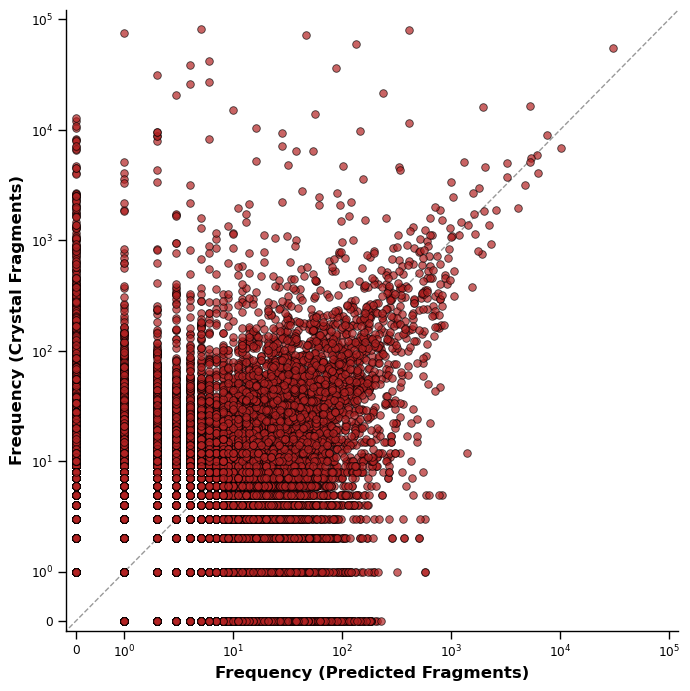

Plot saved successfully to: /home/joan/posal/deliverables/Notebooks/Images/Fragment_Overrepresentation_Symlog.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from rdkit import Chem
from collections import Counter
from tqdm import tqdm
import matplotlib.ticker as ticker
import os
from concurrent.futures import ProcessPoolExecutor, as_completed

# --- CONFIGURATION ---
sns.set_theme(style="whitegrid", context="paper")

CRYSTAL_FRAGMENTS = Path(f'{ZENODO_PATH}/Crystal_Fragments')
SAFR_FRAGMENTS = Path(f'{ZENODO_PATH}/SAFR_v1.0.1')
OUTPUT_DIR = f'{YOUR_PATH}/Images'

NUM_CPUS = 5

os.makedirs(OUTPUT_DIR, exist_ok=True)


# --- MOLECULE PREPARATION ---
def defragment(mol, polarR: bool = False):
    """
    Remove dummy atoms (atomic number 0) and return a cleaned RDKit Mol object.
    """
    fragment = Chem.Mol(mol)

    for atom in fragment.GetAtoms():
        if atom.GetAtomicNum() == 0:
            if polarR:
                neighbors = atom.GetNeighbors()
                if neighbors and neighbors[0].GetSymbol() != "C":
                    atom.SetAtomMapNum(0)
                    atom.SetIsotope(0)
                    continue

            atom.SetAtomicNum(1)
            atom.SetIsotope(0)

    try:
        fragment = Chem.RemoveAllHs(fragment, sanitize=True)
        Chem.SanitizeMol(fragment)
        return fragment
    except Exception:
        return None


# --- DATA PROCESSING WORKER ---
def process_single_sdf(file_path):
    """
    Worker function to process a single SDF file.
    Extracts the 'InchiKey' property, cleans the molecule, gets the SMILES.
    """
    local_counts = Counter()
    local_smiles = {}

    try:
        suppl = Chem.SDMolSupplier(str(file_path), sanitize=False, removeHs=False)
        for raw_mol in suppl:
            if raw_mol is None:
                continue

            try:
                if raw_mol.HasProp("InchiKey"):
                    inchikey = raw_mol.GetProp("InchiKey")
                else:
                    continue

                mol = defragment(raw_mol)
                if mol is None:
                    continue
                smiles = Chem.MolToSmiles(mol)


                local_counts[inchikey] += 1
                if inchikey not in local_smiles:
                    local_smiles[inchikey] = smiles

            except Exception:
                continue
    except Exception:
        pass

    return local_counts, local_smiles


def parse_folder_inchikey(folder_path, label, num_workers):

    print(f"\nProcessing {label} from: {folder_path}")

    files = list(folder_path.rglob('*.sdf'))
    if not files:
        print(f"Warning: No SDF files found in {folder_path} or its subfolders.")

    global_counts = Counter()
    global_smiles = {}

    with ProcessPoolExecutor(max_workers=num_workers) as executor:
        future_to_file = {executor.submit(process_single_sdf, f): f for f in files}

        for future in tqdm(as_completed(future_to_file), total=len(files), desc=f"Reading {label}"):
            res = future.result()
            if res:
                counts, smiles_map = res
                global_counts.update(counts)
                global_smiles.update(smiles_map)

    return pd.Series(global_counts, name=label), global_smiles


# --- EXECUTION ---

counts_a, smiles_a = parse_folder_inchikey(CRYSTAL_FRAGMENTS, 'Crystal_Fragments', NUM_CPUS)
counts_b, smiles_b = parse_folder_inchikey(SAFR_FRAGMENTS, 'Synthetic_Fragments', NUM_CPUS)

print("\nData extracted. Aligning data into dataframe...")
all_smiles = {**smiles_a, **smiles_b}
df_plot = pd.DataFrame([counts_a, counts_b]).T.fillna(0)

df_plot['SMILES'] = df_plot.index.map(all_smiles.get)

csv_path = os.path.join(f"{YOUR_PATH}/Data", "Fragment_Counts_and_Smiles.csv")
df_plot.index.name = "InchiKey"
df_plot.to_csv(csv_path)
print(f"Dataframe saved to: {csv_path}")

print("Generating plot...")
y = df_plot['Crystal_Fragments']
x = df_plot['Synthetic_Fragments']

sns.set_style("white")
plt.figure(figsize=(7, 7))

sns.scatterplot(
        x=x,
        y=y,
        color='firebrick',
        s=30,
        alpha=0.7,
        edgecolor='black',
        linewidth=0.6)

sns.despine()

limit = max(x.max(), y.max()) * 1.5
plt.plot([-1, limit], [-1, limit], ls="--", c=".6", lw=1, zorder=0)
ax = plt.gca()
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.tick_params(axis='both', which='major', length=6, width=1.0, colors='black', direction='out', bottom=True, left=True)
ax.tick_params(axis='both', which='minor', length=3, width=0.5, colors='black', direction='out', bottom=True, left=True)

ax.set_xscale('symlog', linthresh=1, linscale=0.4)
ax.set_yscale('symlog', linthresh=1, linscale=0.4)

ax.set_xlim(left=-0.2, right=limit)
ax.set_ylim(bottom=-0.2, top=limit)

def symlog_formatter(tick_val, pos):
        if tick_val <= 0:
            return '0' if tick_val == 0 else ''
        log_x = np.log10(tick_val)
        if abs(log_x - round(log_x)) < 1e-10:
            return r'$10^{%.0f}$' % round(log_x)
        return ""

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(symlog_formatter))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(symlog_formatter))

plt.xlabel('Frequency (Predicted Fragments)', fontsize=12, color='black', fontweight='bold')
plt.ylabel('Frequency (Crystal Fragments)', fontsize=12, color='black', fontweight='bold')
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, "Fragment_Overrepresentation_Symlog.png")
#plt.savefig(save_path, dpi=500, bbox_inches='tight')
plt.show()

print(f"Plot saved successfully to: {save_path}")

In [ ]:

crystal = df_plot['Crystal_Fragments']
synthetic = df_plot['Synthetic_Fragments']

more_crystal = (crystal > synthetic).sum()
more_synthetic = (synthetic > crystal).sum()
exactly_equal = (crystal == synthetic).sum()
total_points = len(df_plot)

pct_crystal = (more_crystal / total_points) * 100
pct_synthetic = (more_synthetic / total_points) * 100
pct_equal = (exactly_equal / total_points) * 100

print("\n" + "="*30)
print("FRAGMENT DISTRIBUTION STATS")
print("="*30)
print(f"Total Unique Fragments: {total_points}")
print(f"More in Crystal:        {more_crystal} ({pct_crystal:.2f}%)")
print(f"More in Predicted:      {more_synthetic} ({pct_synthetic:.2f}%)")
print(f"Exactly Balanced:       {exactly_equal} ({pct_equal:.2f}%)")
print("-" * 30)

if more_crystal > more_synthetic:
    print("RESULT: Majority of fragments favor CRYSTAL side.")
elif more_synthetic > more_crystal:
    print("RESULT: Majority of fragments favor PREDICTED side.")
else:
    print("RESULT: The distribution is perfectly balanced.")
print("="*30)


FRAGMENT DISTRIBUTION STATS
Total Unique Fragments: 237217
More in Crystal:        92030 (38.80%)
More in Predicted:      141217 (59.53%)
Exactly Balanced:       3970 (1.67%)
------------------------------
RESULT: Majority of fragments favor PREDICTED side.


In [6]:
df_plot.sort_values(by="Synthetic_Fragments", ascending=False, inplace = True)
df_plot[(df_plot["Crystal_Fragments"] == 0)].head(12)

,Crystal_Fragments,Synthetic_Fragments,SMILES
InchiKey,,,
NGXSWUFDCSEIOO-BYPYZUCNSA-O,0.0,228.0,[NH3+][C@H]1CCNC1
ONQBOTKLCMXPOF-UHFFFAOYSA-O,0.0,210.0,CC[NH+]1CCCC1
LCTPALUDPJSACE-YFKPBYRVSA-O,0.0,201.0,O=CN[C@H]1CC[NH2+]C1
KFEHQSLGLJKXMG-UHFFFAOYSA-N,0.0,184.0,Nc1ccc(Oc2ccnc3[nH]ncc23)c(F)c1
HQQFHDDZCKURKT-UHFFFAOYSA-N,0.0,184.0,Fc1ccccc1Oc1ccnc2[nH]ncc12
BWJPTXVPFNFVFM-UHFFFAOYSA-N,0.0,184.0,O=CNc1ccc(Oc2ccnc3[nH]ncc23)c(F)c1
XGBULVIMVCHZSV-BYPYZUCNSA-O,0.0,182.0,NC(=O)N[C@H]1CC[NH2+]C1
MFEOEBMTWBMYAE-ZETCQYMHSA-O,0.0,178.0,CC[N@@H+]1CC[C@H](NC=O)C1
ZKLQIVPPHFQZOK-UHFFFAOYSA-O,0.0,178.0,COCC[NH+]1CCCC1


In [ ]:
from rdkit.Chem import Draw

print("\nDrawing 3x4 grid for top 12 exclusive Synthetic Fragments...")

exclusive_synthetic = df_plot[df_plot["Crystal_Fragments"] == 0].sort_values(by="Synthetic_Fragments", ascending=False).head(12)

mols = [Chem.MolFromSmiles(smiles) for smiles in exclusive_synthetic['SMILES']]


legends = [f"N: {int(count)}" for count in exclusive_synthetic['Synthetic_Fragments']]


dopts = Draw.rdMolDraw2D.MolDrawOptions()
dopts.useBWAtomPalette()
dopts.setBackgroundColour((1, 1, 1))
dopts.bondLineWidth = 4.0
dopts.minFontSize = 30
dopts.fixedBondLength = 40
dopts.additionalAtomLabelPadding = 0.1
dopts.addStereoAnnotation = True
dopts.legendFontSize = 40
dopts.legendFraction = 0.2

grid_img = Draw.MolsToGridImage(
        mols,
        molsPerRow=3,
        subImgSize=(400, 400),
        legends=legends,
        drawOptions=dopts,
        returnPNG=False )


grid_save_path = os.path.join(OUTPUT_DIR, "SAFR_Exclusive_Top12_Grid.png")
grid_img.save(grid_save_path)
print(f"Molecule grid saved successfully to: {grid_save_path}")


Drawing 3x4 grid for top 12 exclusive Synthetic Fragments...
Molecule grid saved successfully to: /home/joan/posal/deliverables/Notebooks/Images/SAFR_Exclusive_Top12_Grid.png


In [ ]:
from rdkit.Chem import Draw

print("\nDrawing 3x4 grid for top 12 exclusive Crystal Fragments...")

exclusive_synthetic = df_plot[df_plot["Synthetic_Fragments"] == 0].sort_values(by="Crystal_Fragments", ascending=False).head(12)

mols = [Chem.MolFromSmiles(smiles) for smiles in exclusive_synthetic['SMILES']]


legends = [f"N: {int(count)}" for count in exclusive_synthetic['Crystal_Fragments']]


dopts = Draw.rdMolDraw2D.MolDrawOptions()
dopts.useBWAtomPalette()
dopts.setBackgroundColour((1, 1, 1))
dopts.bondLineWidth = 4.0
dopts.minFontSize = 30
dopts.fixedBondLength = 40
dopts.additionalAtomLabelPadding = 0.1
dopts.addStereoAnnotation = True
dopts.legendFontSize = 40
dopts.legendFraction = 0.2

grid_img = Draw.MolsToGridImage(
        mols,
        molsPerRow=3,
        subImgSize=(400, 400),
        legends=legends,
        drawOptions=dopts,
        returnPNG=False )


grid_save_path = os.path.join(OUTPUT_DIR, "Crystal_Exclusive_Top12_Grid.png")
grid_img.save(grid_save_path)
print(f"Molecule grid saved successfully to: {grid_save_path}")


Drawing 3x4 grid for top 12 exclusive Crystal Fragments...
Molecule grid saved successfully to: /home/joan/posal/deliverables/Notebooks/Images/Crystal_Exclusive_Top12_Grid.png


In [ ]:
from rdkit.Chem import Draw
from IPython.display import display, Image

print("Drawing the top 15 SAFR Fragments individually...\n")

top_crystal = df_plot.sort_values(by="Synthetic_Fragments", ascending=False).head(15)


for rank, (inchikey, row) in enumerate(top_crystal.iterrows(), start=1):
    smiles = row['SMILES']
    count = int(row['Synthetic_Fragments'])
    mol = Chem.MolFromSmiles(smiles)
    print(row)

    if mol is None:
        continue


    d2d = Draw.rdMolDraw2D.MolDraw2DCairo(400, 400)

    dopts = d2d.drawOptions()
    dopts.useBWAtomPalette()
    dopts.setBackgroundColour((1, 1, 1))
    dopts.bondLineWidth = 4.0
    dopts.minFontSize = 30
    dopts.fixedBondLength = 40
    dopts.additionalAtomLabelPadding = 0.1
    dopts.addStereoAnnotation = True


    legend_text = f"Rank {rank} | N: {count}"
    d2d.DrawMolecule(mol, legend=legend_text)
    d2d.FinishDrawing()

    display(Image(d2d.GetDrawingText()))

In [ ]:
from rdkit.Chem import Draw
from IPython.display import display, Image

print("Drawing the top 15 Crystal Fragments individually...\n")

top_crystal = df_plot.sort_values(by="Crystal_Fragments", ascending=False).head(15)


for rank, (inchikey, row) in enumerate(top_crystal.iterrows(), start=1):
    smiles = row['SMILES']
    count = int(row['Crystal_Fragments'])
    mol = Chem.MolFromSmiles(smiles)
    print(row)

    if mol is None:
        continue

    d2d = Draw.rdMolDraw2D.MolDraw2DCairo(400, 400)

    dopts = d2d.drawOptions()
    dopts.useBWAtomPalette()
    dopts.setBackgroundColour((1, 1, 1))
    dopts.bondLineWidth = 4.0
    dopts.minFontSize = 30
    dopts.fixedBondLength = 40
    dopts.additionalAtomLabelPadding = 0.1
    dopts.addStereoAnnotation = True


    legend_text = f"Rank {rank} | N: {count}"
    d2d.DrawMolecule(mol, legend=legend_text)
    d2d.FinishDrawing()


    display(Image(d2d.GetDrawingText()))

### The same but for murcko scaffolds


Processing Crystal_Fragments from: /home/joan/posal/deliverables/Crystal_Scaffolds


Reading Crystal_Fragments:  31%|███       | 6578/21535 [00:25<00:37, 400.51it/s][11:39:19] unrecognized chirality tag (6) on atom 4 is ignored.
[11:39:19] unrecognized chirality tag (6) on atom 4 is ignored.
[11:39:19] unrecognized chirality tag (6) on atom 1 is ignored.
[11:39:19] unrecognized chirality tag (6) on atom 1 is ignored.
Reading Crystal_Fragments:  78%|███████▊  | 16720/21535 [01:04<00:13, 368.28it/s][11:39:58] unrecognized chirality tag (6) on atom 9 is ignored.
[11:39:58] unrecognized chirality tag (6) on atom 9 is ignored.
[11:39:58] unrecognized chirality tag (6) on atom 11 is ignored.
[11:39:58] unrecognized chirality tag (6) on atom 11 is ignored.
Reading Crystal_Fragments:  93%|█████████▎| 19951/21535 [01:16<00:05, 308.96it/s][11:40:11] unrecognized chirality tag (6) on atom 5 is ignored.
[11:40:11] unrecognized chirality tag (6) on atom 5 is ignored.
[11:40:11] unrecognized chirality tag (6) on atom 5 is ignored.
[11:40:11] unrecognized chirality tag (6) on atom 5 


Processing Synthetic_Fragments from: /home/joan/posal/deliverables/SAFR_Scaffolds



Reading Synthetic_Fragments: 100%|██████████| 1142/1142 [00:38<00:00, 29.81it/s]



Data extracted. Aligning data into dataframe...
Dataframe saved to: /home/joan/posal/deliverables/Notebooks/Images/Fragment_Scaffolds_Counts_and_Smiles.csv
Generating plot...


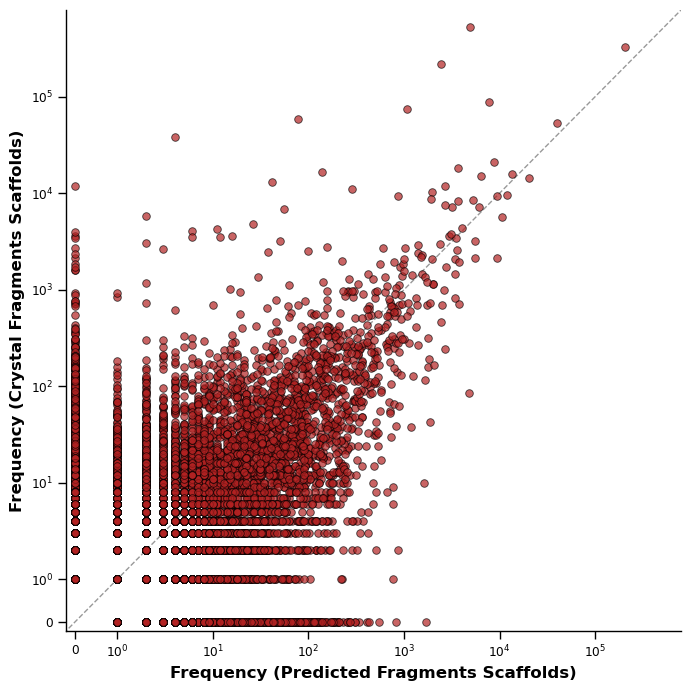

Plot saved successfully to: /home/joan/posal/deliverables/Notebooks/Images/Fragment_Scaffold_Overrepresentation_Symlog.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from rdkit import Chem
from collections import Counter
from tqdm import tqdm
import matplotlib.ticker as ticker
import os
from concurrent.futures import ProcessPoolExecutor, as_completed

# --- CONFIGURATION ---
sns.set_theme(style="whitegrid", context="paper")

CRYSTAL_FRAGMENTS = Path('/home/joan/posal/deliverables/Crystal_Scaffolds')
SAFR_FRAGMENTS = Path('/home/joan/posal/deliverables/SAFR_Scaffolds')
OUTPUT_DIR = f'{YOUR_PATH}/Images'

NUM_CPUS = 5

os.makedirs(OUTPUT_DIR, exist_ok=True)


# --- MOLECULE PREPARATION ---
def defragment(mol, polarR: bool = False):
    """
    Remove dummy atoms (atomic number 0) and return a cleaned RDKit Mol object.
    """
    fragment = Chem.Mol(mol)

    for atom in fragment.GetAtoms():
        if atom.GetAtomicNum() == 0:
            if polarR:
                neighbors = atom.GetNeighbors()
                if neighbors and neighbors[0].GetSymbol() != "C":
                    atom.SetAtomMapNum(0)
                    atom.SetIsotope(0)
                    continue

            atom.SetAtomicNum(1)
            atom.SetIsotope(0)

    try:
        fragment = Chem.RemoveAllHs(fragment, sanitize=True)
        Chem.SanitizeMol(fragment)
        return fragment
    except Exception:
        return None


# --- DATA PROCESSING WORKER ---
def process_single_sdf(file_path):
    """
    Worker function to process a single SDF file.
    Extracts the 'InchiKey' property, cleans the molecule, gets the SMILES.
    """
    local_counts = Counter()
    local_smiles = {}

    try:
        suppl = Chem.SDMolSupplier(str(file_path), sanitize=False, removeHs=False)
        for raw_mol in suppl:
            if raw_mol is None:
                continue

            try:


                mol = defragment(raw_mol)
                if mol is None:
                    continue
                inchikey = Chem.MolToInchiKey(mol)
                smiles = Chem.MolToSmiles(mol)


                local_counts[inchikey] += 1
                if inchikey not in local_smiles:
                    local_smiles[inchikey] = smiles

            except Exception:
                continue
    except Exception:
        pass

    return local_counts, local_smiles


def parse_folder_inchikey(folder_path, label, num_workers):

    print(f"\nProcessing {label} from: {folder_path}")

    files = list(folder_path.rglob('*.sdf'))
    if not files:
        print(f"Warning: No SDF files found in {folder_path} or its subfolders.")

    global_counts = Counter()
    global_smiles = {}

    with ProcessPoolExecutor(max_workers=num_workers) as executor:
        future_to_file = {executor.submit(process_single_sdf, f): f for f in files}

        for future in tqdm(as_completed(future_to_file), total=len(files), desc=f"Reading {label}"):
            res = future.result()
            if res:
                counts, smiles_map = res
                global_counts.update(counts)
                global_smiles.update(smiles_map)

    return pd.Series(global_counts, name=label), global_smiles


# --- EXECUTION ---

counts_a, smiles_a = parse_folder_inchikey(CRYSTAL_FRAGMENTS, 'Crystal_Fragments', NUM_CPUS)
counts_b, smiles_b = parse_folder_inchikey(SAFR_FRAGMENTS, 'Synthetic_Fragments', NUM_CPUS)

print("\nData extracted. Aligning data into dataframe...")
all_smiles = {**smiles_a, **smiles_b}
df_plot = pd.DataFrame([counts_a, counts_b]).T.fillna(0)

df_plot['SMILES'] = df_plot.index.map(all_smiles.get)

csv_path = os.path.join(f"{YOUR_PATH}/Data", "Fragment_Scaffolds_Counts_and_Smiles.csv")
df_plot.index.name = "InchiKey"
df_plot.to_csv(csv_path)
print(f"Dataframe saved to: {csv_path}")

print("Generating plot...")
y = df_plot['Crystal_Fragments']
x = df_plot['Synthetic_Fragments']

sns.set_style("white")
plt.figure(figsize=(7, 7))

sns.scatterplot(
        x=x,
        y=y,
        color='firebrick',
        s=30,
        alpha=0.7,
        edgecolor='black',
        linewidth=0.6)

sns.despine()

limit = max(x.max(), y.max()) * 1.5
plt.plot([-1, limit], [-1, limit], ls="--", c=".6", lw=1, zorder=0)
ax = plt.gca()
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.tick_params(axis='both', which='major', length=6, width=1.0, colors='black', direction='out', bottom=True, left=True)
ax.tick_params(axis='both', which='minor', length=3, width=0.5, colors='black', direction='out', bottom=True, left=True)

ax.set_xscale('symlog', linthresh=1, linscale=0.4)
ax.set_yscale('symlog', linthresh=1, linscale=0.4)

ax.set_xlim(left=-0.2, right=limit)
ax.set_ylim(bottom=-0.2, top=limit)

def symlog_formatter(tick_val, pos):
        if tick_val <= 0:
            return '0' if tick_val == 0 else ''
        log_x = np.log10(tick_val)
        if abs(log_x - round(log_x)) < 1e-10:
            return r'$10^{%.0f}$' % round(log_x)
        return ""

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(symlog_formatter))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(symlog_formatter))

plt.xlabel('Frequency (Predicted Fragments Scaffolds)', fontsize=12, color='black', fontweight='bold')
plt.ylabel('Frequency (Crystal Fragments Scaffolds)', fontsize=12, color='black', fontweight='bold')
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, "Fragment_Scaffold_Overrepresentation_Symlog.png")
plt.savefig(save_path, dpi=500, bbox_inches='tight')
plt.show()

print(f"Plot saved successfully to: {save_path}")

In [ ]:
import pandas as pd
df_plot = pd.read_csv(os.path.join(f"{YOUR_PATH}/Data","Fragment_Scaffolds_Counts_and_Smiles.csv"))
crystal = df_plot['Crystal_Fragments']
synthetic = df_plot['Synthetic_Fragments']

more_crystal = (crystal > synthetic).sum()
more_synthetic = (synthetic > crystal).sum()
exactly_equal = (crystal == synthetic).sum()
total_points = len(df_plot)

pct_crystal = (more_crystal / total_points) * 100
pct_synthetic = (more_synthetic / total_points) * 100
pct_equal = (exactly_equal / total_points) * 100

print("\n" + "="*30)
print("FRAGMENT DISTRIBUTION STATS")
print("="*30)
print(f"Total Unique scaffolds: {total_points}")
print(f"More in Crystal:        {more_crystal} ({pct_crystal:.2f}%)")
print(f"More in Predicted:      {more_synthetic} ({pct_synthetic:.2f}%)")
print(f"Exactly Balanced:       {exactly_equal} ({pct_equal:.2f}%)")
print(f"Count only Predicted:   {len(df_plot[df_plot['Crystal_Fragments'] == 0])}")
print(f"Count only Crystal:   {len(df_plot[df_plot['Synthetic_Fragments'] == 0])}")
print("-" * 30)

if more_crystal > more_synthetic:
    print("RESULT: Majority of scaffolds favor CRYSTAL side.")
elif more_synthetic > more_crystal:
    print("RESULT: Majority of scaffolds favor PREDICTED side.")
else:
    print("RESULT: The distribution is perfectly balanced.")
print("="*30)


FRAGMENT DISTRIBUTION STATS
Total Unique scaffolds: 32147
More in Crystal:        12498 (38.88%)
More in Predicted:      19165 (59.62%)
Exactly Balanced:       484 (1.51%)
Count only Predicted:   16517
Count only Crystal:   10020
------------------------------
RESULT: Majority of scaffolds favor PREDICTED side.


In [28]:
from rdkit.Chem import Draw

print("\nDrawing 3x4 grid for top 12 exclusive Synthetic Fragments...")

exclusive_synthetic = df_plot[df_plot["Crystal_Fragments"] == 0].sort_values(by="Synthetic_Fragments", ascending=False).head(12)

mols = [Chem.MolFromSmiles(smiles) for smiles in exclusive_synthetic['SMILES']]


legends = [f"N: {int(count)}" for count in exclusive_synthetic['Synthetic_Fragments']]


dopts = Draw.rdMolDraw2D.MolDrawOptions()
dopts.useBWAtomPalette()
dopts.setBackgroundColour((1, 1, 1))
dopts.bondLineWidth = 4.0
dopts.minFontSize = 30
dopts.fixedBondLength = 40
dopts.additionalAtomLabelPadding = 0.1
dopts.addStereoAnnotation = True
dopts.legendFontSize = 40
dopts.legendFraction = 0.2

grid_img = Draw.MolsToGridImage(
        mols,
        molsPerRow=3,
        subImgSize=(400, 400),
        legends=legends,
        drawOptions=dopts,
        returnPNG=False )


grid_save_path = os.path.join(OUTPUT_DIR, "SAFR_Exclusive_Top12_Scaffolds_Grid.png")
grid_img.save(grid_save_path)
print(f"Molecule grid saved successfully to: {grid_save_path}")


Drawing 3x4 grid for top 12 exclusive Synthetic Fragments...
Molecule grid saved successfully to: /home/joan/posal/deliverables/Notebooks/Images/SAFR_Exclusive_Top12_Scaffolds_Grid.png


In [32]:
from rdkit.Chem import Draw

print("\nDrawing 3x4 grid for top 12 exclusive Crystal Fragments...")

exclusive_synthetic = df_plot[df_plot["Synthetic_Fragments"] == 0].sort_values(by="Crystal_Fragments", ascending=False).head(12)

mols = [Chem.MolFromSmiles(smiles) for smiles in exclusive_synthetic['SMILES']]


legends = [f"N: {int(count)}" for count in exclusive_synthetic['Crystal_Fragments']]


dopts = Draw.rdMolDraw2D.MolDrawOptions()
dopts.useBWAtomPalette()
dopts.setBackgroundColour((1, 1, 1))
dopts.bondLineWidth = 4.0
dopts.minFontSize = 30
dopts.fixedBondLength = 40
dopts.additionalAtomLabelPadding = 0.1
dopts.addStereoAnnotation = True
dopts.legendFontSize = 40
dopts.legendFraction = 0.2

grid_img = Draw.MolsToGridImage(
        mols,
        molsPerRow=3,
        subImgSize=(400, 400),
        legends=legends,
        drawOptions=dopts,
        returnPNG=False )


grid_save_path = os.path.join(OUTPUT_DIR, "Crystal_Exclusive_Top12_Scaffolds_Grid.png")
grid_img.save(grid_save_path)
print(f"Molecule grid saved successfully to: {grid_save_path}")


Drawing 3x4 grid for top 12 exclusive Crystal Fragments...
Molecule grid saved successfully to: /home/joan/posal/deliverables/Notebooks/Images/Crystal_Exclusive_Top12_Scaffolds_Grid.png


Drawing the top 15 SAFR Fragments individually...

Crystal_Fragments      328578.0
Synthetic_Fragments    204098.0
SMILES                 c1ccccc1
Name: UHOVQNZJYSORNB-UHFFFAOYSA-N, dtype: object


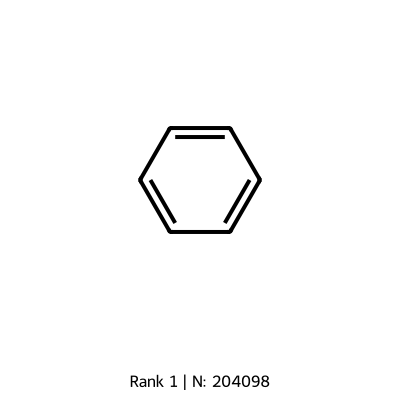

Crystal_Fragments       53254.0
Synthetic_Fragments     39871.0
SMILES                 c1ccncc1
Name: JUJWROOIHBZHMG-UHFFFAOYSA-N, dtype: object


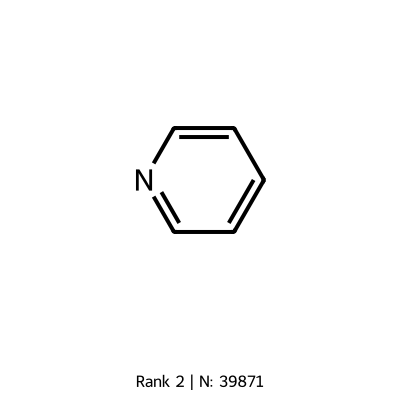

Crystal_Fragments       14262.0
Synthetic_Fragments     20525.0
SMILES                 c1cncnc1
Name: CZPWVGJYEJSRLH-UHFFFAOYSA-N, dtype: object


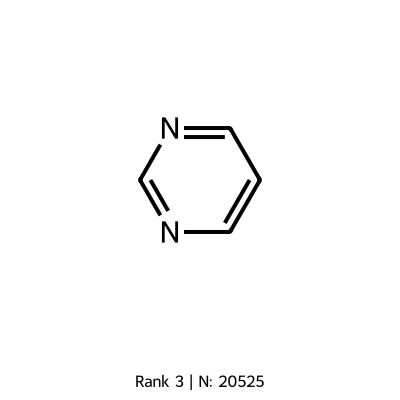

Crystal_Fragments       15960.0
Synthetic_Fragments     13522.0
SMILES                 C1CCNCC1
Name: NQRYJNQNLNOLGT-UHFFFAOYSA-N, dtype: object


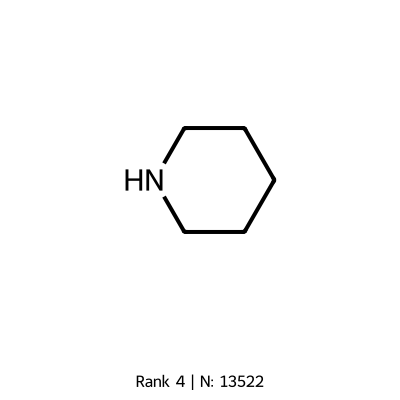

Crystal_Fragments       9679.0
Synthetic_Fragments    11994.0
SMILES                   C1CC1
Name: LVZWSLJZHVFIQJ-UHFFFAOYSA-N, dtype: object


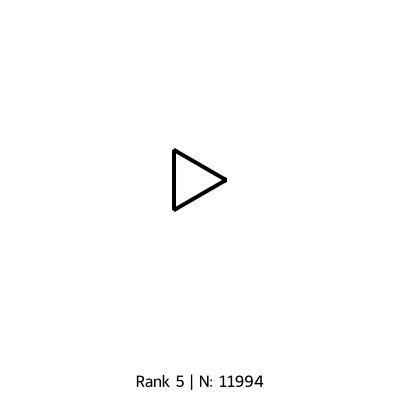

Crystal_Fragments              5711.0
Synthetic_Fragments           10615.0
SMILES                 c1ccc2ncccc2c1
Name: SMWDFEZZVXVKRB-UHFFFAOYSA-N, dtype: object


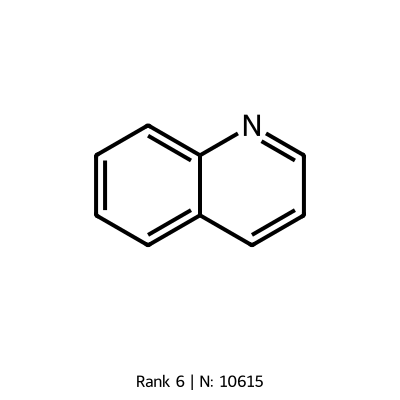

Crystal_Fragments          9384.0
Synthetic_Fragments        9354.0
SMILES                 c1cn[nH]c1
Name: WTKZEGDFNFYCGP-UHFFFAOYSA-N, dtype: object


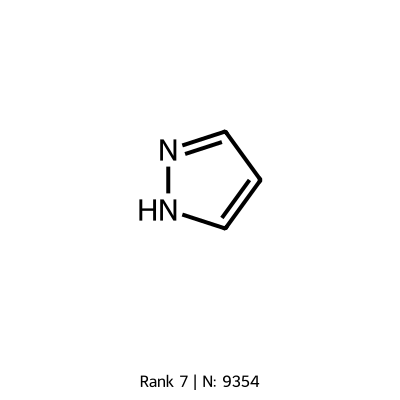

Crystal_Fragments                  2126.0
Synthetic_Fragments                9298.0
SMILES                 c1ccc(-n2cccn2)cc1
Name: WITMXBRCQWOZPX-UHFFFAOYSA-N, dtype: object


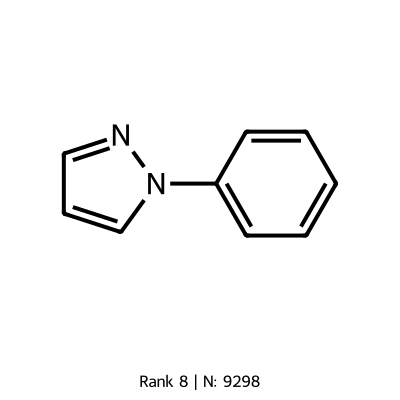

Crystal_Fragments       20836.0
Synthetic_Fragments      8701.0
SMILES                 C1CCCCC1
Name: XDTMQSROBMDMFD-UHFFFAOYSA-N, dtype: object


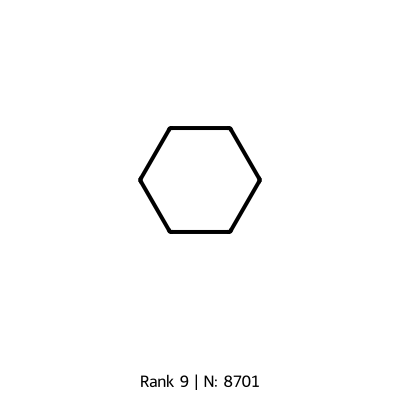

Crystal_Fragments      87692.0
Synthetic_Fragments     7724.0
SMILES                 C1CCNC1
Name: RWRDLPDLKQPQOW-UHFFFAOYSA-N, dtype: object


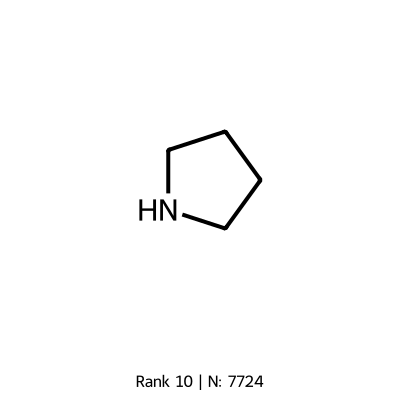

Crystal_Fragments               14987.0
Synthetic_Fragments              6376.0
SMILES                 c1ccc2[nH]ccc2c1
Name: SIKJAQJRHWYJAI-UHFFFAOYSA-N, dtype: object


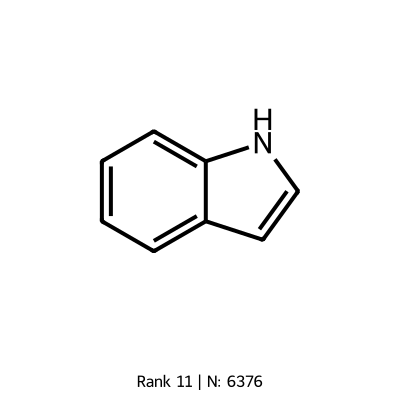

Crystal_Fragments                   7235.0
Synthetic_Fragments                 6118.0
SMILES                 c1ccc(-c2ccccc2)cc1
Name: ZUOUZKKEUPVFJK-UHFFFAOYSA-N, dtype: object


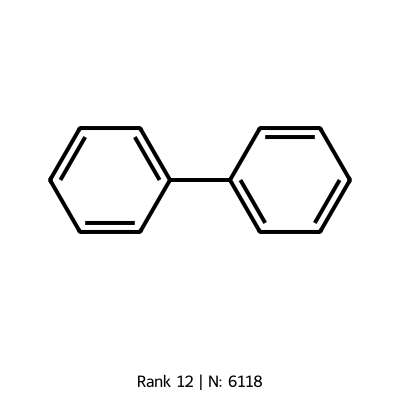

Crystal_Fragments       2139.0
Synthetic_Fragments     5571.0
SMILES                 c1nncs1
Name: MBIZXFATKUQOOA-UHFFFAOYSA-N, dtype: object


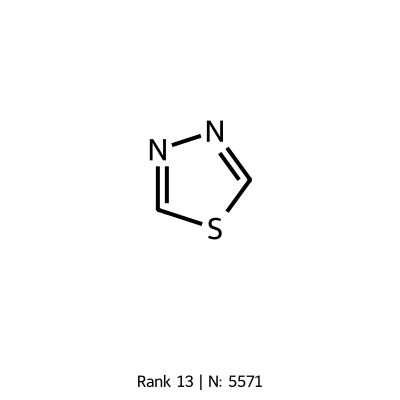

Crystal_Fragments              3167.0
Synthetic_Fragments            5498.0
SMILES                 c1ccc2ncncc2c1
Name: JWVCLYRUEFBMGU-UHFFFAOYSA-N, dtype: object


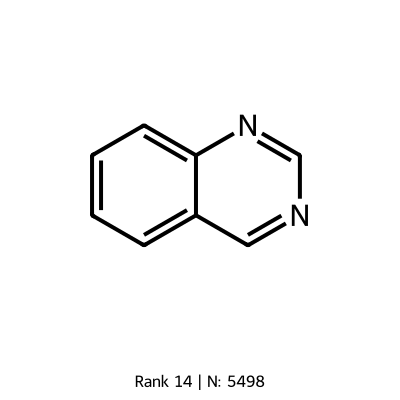

Crystal_Fragments       8510.0
Synthetic_Fragments     5231.0
SMILES                 c1cscn1
Name: FZWLAAWBMGSTSO-UHFFFAOYSA-N, dtype: object


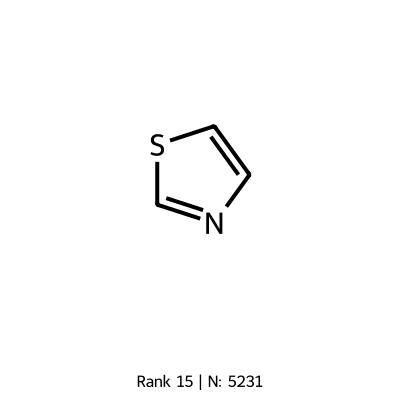

In [38]:
from rdkit.Chem import Draw
from IPython.display import display, Image

print("Drawing the top 15 SAFR Fragments individually...\n")

top_crystal = df_plot.sort_values(by="Synthetic_Fragments", ascending=False).head(15)


for rank, (inchikey, row) in enumerate(top_crystal.iterrows(), start=1):
    smiles = row['SMILES']
    count = int(row['Synthetic_Fragments'])
    mol = Chem.MolFromSmiles(smiles)
    print(row)

    if mol is None:
        continue


    d2d = Draw.rdMolDraw2D.MolDraw2DCairo(400, 400)

    dopts = d2d.drawOptions()
    dopts.useBWAtomPalette()
    dopts.setBackgroundColour((1, 1, 1))
    dopts.bondLineWidth = 4.0
    dopts.minFontSize = 30
    dopts.fixedBondLength = 40
    dopts.additionalAtomLabelPadding = 0.1
    dopts.addStereoAnnotation = True


    legend_text = f"Rank {rank} | N: {count}"
    d2d.DrawMolecule(mol, legend=legend_text)
    d2d.FinishDrawing()

    display(Image(d2d.GetDrawingText()))

Drawing the top 15 Crystal Fragments individually...

Crystal_Fragments      531300.0
Synthetic_Fragments      4960.0
SMILES                 C1CCOCC1
Name: DHXVGJBLRPWPCS-UHFFFAOYSA-N, dtype: object


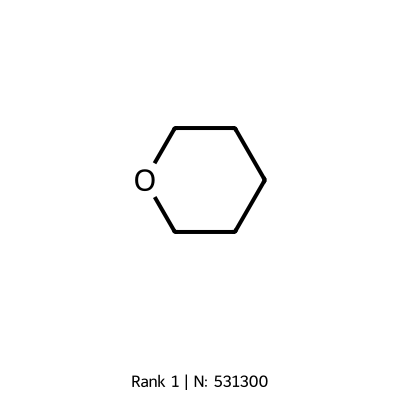

Crystal_Fragments      328578.0
Synthetic_Fragments    204098.0
SMILES                 c1ccccc1
Name: UHOVQNZJYSORNB-UHFFFAOYSA-N, dtype: object


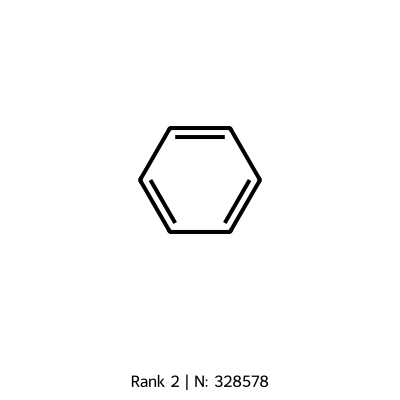

Crystal_Fragments      216416.0
Synthetic_Fragments      2432.0
SMILES                  C1CCOC1
Name: WYURNTSHIVDZCO-UHFFFAOYSA-N, dtype: object


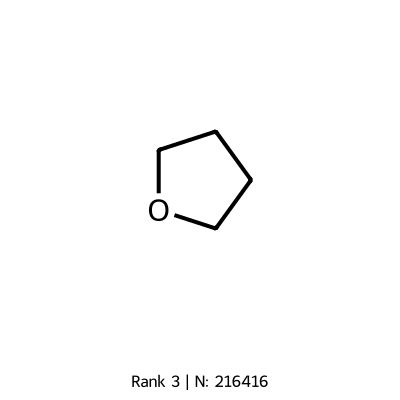

Crystal_Fragments      87692.0
Synthetic_Fragments     7724.0
SMILES                 C1CCNC1
Name: RWRDLPDLKQPQOW-UHFFFAOYSA-N, dtype: object


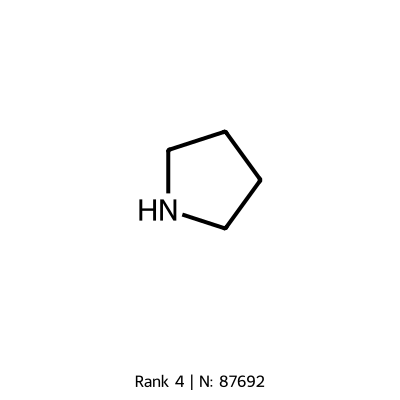

Crystal_Fragments               75032.0
Synthetic_Fragments              1083.0
SMILES                 c1ncc2nc[nH]c2n1
Name: KDCGOANMDULRCW-UHFFFAOYSA-N, dtype: object


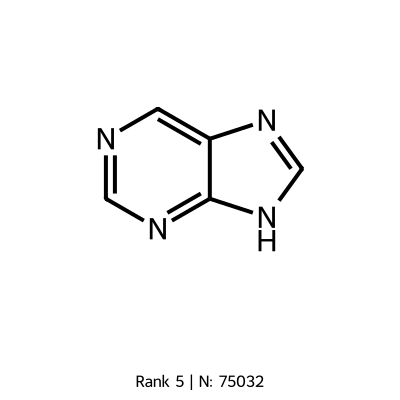

Crystal_Fragments        58910.0
Synthetic_Fragments         78.0
SMILES                 C1=CCCCC1
Name: HGCIXCUEYOPUTN-UHFFFAOYSA-N, dtype: object


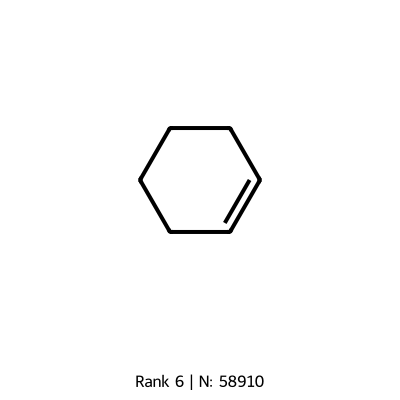

Crystal_Fragments       53254.0
Synthetic_Fragments     39871.0
SMILES                 c1ccncc1
Name: JUJWROOIHBZHMG-UHFFFAOYSA-N, dtype: object


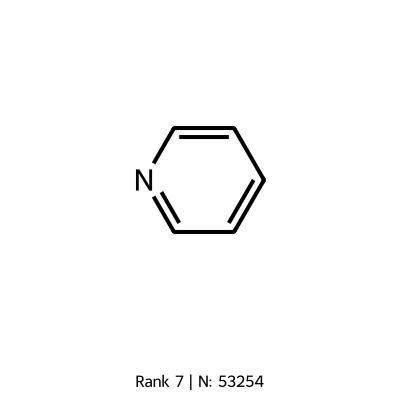

Crystal_Fragments                       38457.0
Synthetic_Fragments                         4.0
SMILES                 c1cc[n+]([C@H]2CCCO2)cc1
Name: ORQPLHWXILGEPQ-SECBINFHSA-N, dtype: object


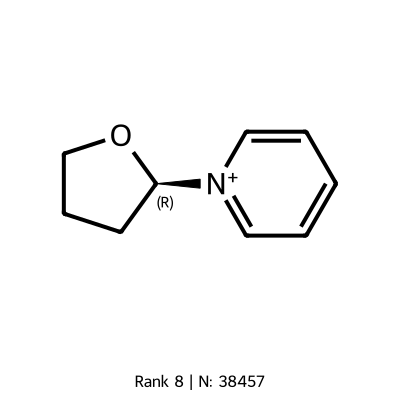

Crystal_Fragments       20836.0
Synthetic_Fragments      8701.0
SMILES                 C1CCCCC1
Name: XDTMQSROBMDMFD-UHFFFAOYSA-N, dtype: object


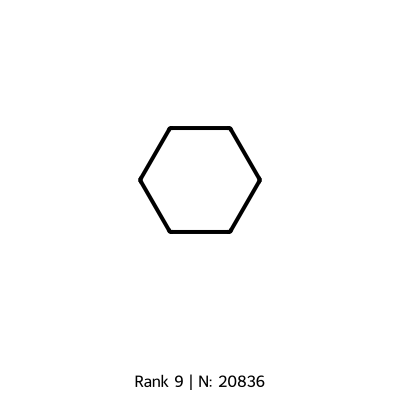

Crystal_Fragments       18429.0
Synthetic_Fragments      3652.0
SMILES                 C1CNCCN1
Name: GLUUGHFHXGJENI-UHFFFAOYSA-N, dtype: object


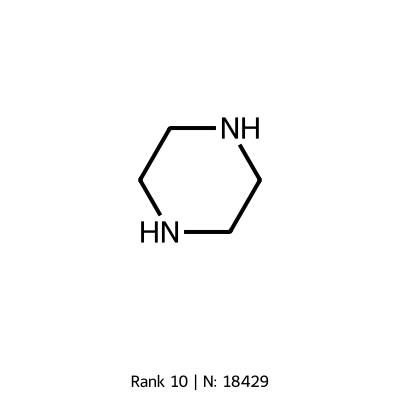

Crystal_Fragments                    16663.0
Synthetic_Fragments                    138.0
SMILES                 O=c1[nH]cnc2[nH]cnc12
Name: FDGQSTZJBFJUBT-UHFFFAOYSA-N, dtype: object


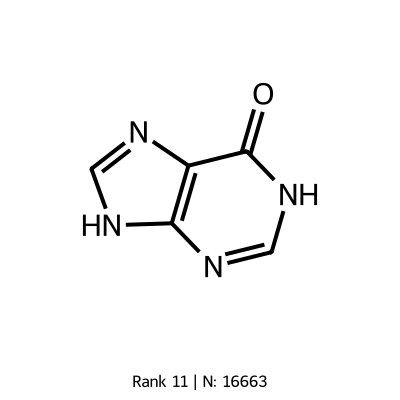

Crystal_Fragments       15960.0
Synthetic_Fragments     13522.0
SMILES                 C1CCNCC1
Name: NQRYJNQNLNOLGT-UHFFFAOYSA-N, dtype: object


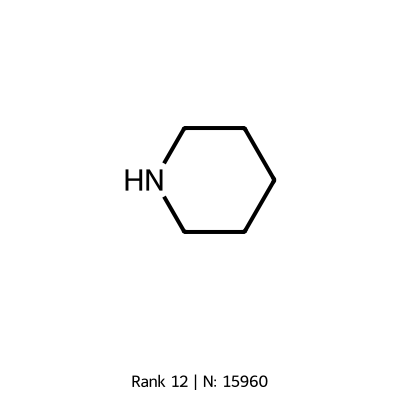

Crystal_Fragments               14987.0
Synthetic_Fragments              6376.0
SMILES                 c1ccc2[nH]ccc2c1
Name: SIKJAQJRHWYJAI-UHFFFAOYSA-N, dtype: object


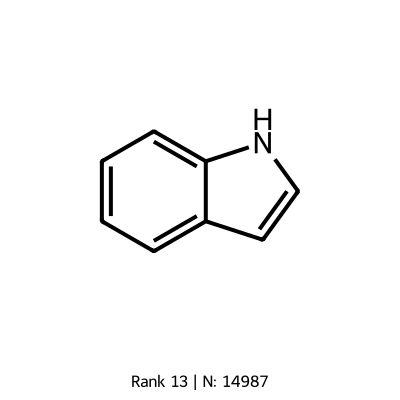

Crystal_Fragments       14262.0
Synthetic_Fragments     20525.0
SMILES                 c1cncnc1
Name: CZPWVGJYEJSRLH-UHFFFAOYSA-N, dtype: object


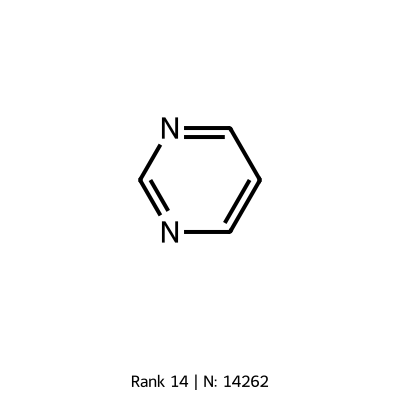

Crystal_Fragments                             13005.0
Synthetic_Fragments                              42.0
SMILES                 O=c1ccn([C@H]2CCCO2)c(=O)[nH]1
Name: CWWIKVUHBBTKHC-SSDOTTSWSA-N, dtype: object


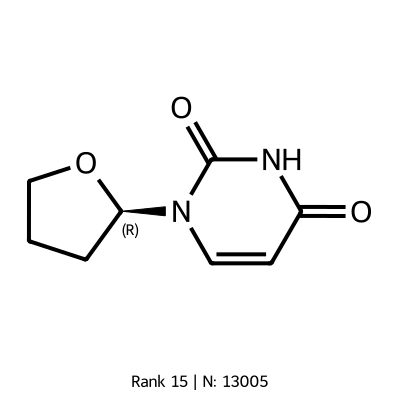

In [39]:
from rdkit.Chem import Draw
from IPython.display import display, Image

print("Drawing the top 15 Crystal Fragments individually...\n")

top_crystal = df_plot.sort_values(by="Crystal_Fragments", ascending=False).head(15)


for rank, (inchikey, row) in enumerate(top_crystal.iterrows(), start=1):
    smiles = row['SMILES']
    count = int(row['Crystal_Fragments'])
    mol = Chem.MolFromSmiles(smiles)
    print(row)

    if mol is None:
        continue

    d2d = Draw.rdMolDraw2D.MolDraw2DCairo(400, 400)

    dopts = d2d.drawOptions()
    dopts.useBWAtomPalette()
    dopts.setBackgroundColour((1, 1, 1))
    dopts.bondLineWidth = 4.0
    dopts.minFontSize = 30
    dopts.fixedBondLength = 40
    dopts.additionalAtomLabelPadding = 0.1
    dopts.addStereoAnnotation = True


    legend_text = f"Rank {rank} | N: {count}"
    d2d.DrawMolecule(mol, legend=legend_text)
    d2d.FinishDrawing()


    display(Image(d2d.GetDrawingText()))

# Analysis Scaffolds from SAIR vs SAFR fragmentation

In [ ]:
df_plot = pd.read_csv(f'{YOUR_PATH}/DataSAIR_target_inchikey_counts.csv')
df = df_plot
targets_in_sair = set(df[df['SAIR'] > 0]['Target'])
targets_in_safr = set(df[df['SAFR'] > 0]['Target'])

common_targets = targets_in_sair.intersection(targets_in_safr)

df_not_common = df[~df['Target'].isin(common_targets)].copy()


only_in_safr = df_not_common[df_not_common["SAIR"] == 0]


print(f"Number of targets only in SAFR: {len(common_targets)}")
print(f"Scaffolds found ONLY in SAFR for these targets: {len(only_in_safr)}")
print(f"Fragment poses: {sum(only_in_safr['SAFR'])}")



Number of targets only in SAFR: 925
Scaffolds found ONLY in SAFR for these targets: 3889
Fragment poses: 57350


# Predicted Fragments per Target

In [ ]:
import os
import pandas as pd
from pathlib import Path
from rdkit import Chem
from tqdm import tqdm

PREDICTED_MAIN_FOLDER = f'{ZENODO_PATH}/SAFR_v1.0.1'
CRYSTAL_MAIN_FOLDER = f'{ZENODO_PATH}/Crystal_Fragments'
OUTPUT_DIR = f'{YOUR_PATH}/Images'

os.makedirs(OUTPUT_DIR, exist_ok=True)

def get_fragment_target_pairs(main_folder_path, label):
    """
    Returns a set of tuples: (target_name, smiles)
    """
    main_path = Path(main_folder_path)
    pairs = set()

    if not main_path.exists():
        print(f"Error: Path {main_path} does not exist.")
        return pairs

    subdirs = [d for d in main_path.iterdir() if d.is_dir()]

    print(f"\nProcessing {label} set...")
    for target_dir in tqdm(subdirs, desc=f"Extracting {label} pairs"):
        target_name = target_dir.name

        for sdf_file in target_dir.rglob('*.sdf'):
            try:
                suppl = Chem.SDMolSupplier(str(sdf_file), sanitize=True, removeHs=True)
                for mol in suppl:
                    if mol is not None:
                        smiles = Chem.MolToSmiles(mol, isomericSmiles=True)
                        pairs.add((target_name, smiles))
            except Exception:
                continue
    return pairs


safr_pairs = get_fragment_target_pairs(PREDICTED_MAIN_FOLDER, "SAFR (Predicted)")
crystal_pairs = get_fragment_target_pairs(CRYSTAL_MAIN_FOLDER, "Crystal")


total_safr = len(safr_pairs)
total_crystal = len(crystal_pairs)


only_in_safr = safr_pairs - crystal_pairs
num_only_in_safr = len(only_in_safr)

overlap = safr_pairs & crystal_pairs
num_overlap = len(overlap)

print("\n" + "="*30)
print("FRAGMENT-TARGET STATISTICS")
print("="*30)
print(f"Total unique pairs (SAFR):    {total_safr}")
print(f"Total unique pairs (Crystal): {total_crystal}")
print(f"Common to both:               {num_overlap}")
print(f"Unique to SAFR (Novel):       {num_only_in_safr}")
print(f"Unique to Crystal:            {len(crystal_pairs - safr_pairs)}")
print("-" * 30)

df_novel = pd.DataFrame(list(only_in_safr), columns=['Target_Name', 'SMILES'])
novel_path = os.path.join(f"{YOUR_PATH}/Data" "SAFR_exclusive_pairs.csv")
df_novel.to_csv(novel_path, index=False)
print(f"Novel pairs saved to: {novel_path}")


Processing SAFR (Predicted) set...


Extracting SAFR (Predicted) pairs:  14%|█▍        | 165/1142 [00:24<02:45,  5.90it/s][14:43:21] WARNING: not removing hydrogen atom with neighbor that has non-tetrahedral stereochemistry
[14:43:21] WARNING: not removing hydrogen atom with neighbor that has non-tetrahedral stereochemistry
Extracting SAFR (Predicted) pairs:  60%|█████▉    | 683/1142 [01:35<00:56,  8.18it/s][14:44:33] WARNING: not removing hydrogen atom with neighbor that has non-tetrahedral stereochemistry
[14:44:33] WARNING: not removing hydrogen atom with neighbor that has non-tetrahedral stereochemistry
Extracting SAFR (Predicted) pairs: 100%|██████████| 1142/1142 [02:55<00:00,  6.51it/s]



Processing Crystal set...


Extracting Crystal pairs: 100%|██████████| 21535/21535 [06:27<00:00, 55.57it/s] 



FRAGMENT-TARGET STATISTICS
Total unique pairs (SAFR):    270155
Total unique pairs (Crystal): 390169
Common to both:               32871
Unique to SAFR (Novel):       237284
Unique to Crystal:            357298
------------------------------
Novel pairs saved to: /home/joan/posal/deliverables/Notebooks/Images/SAFR_exclusive_pairs.csv


In [3]:
237284/270155

0.8783254057855675


Scanning 'Predicted' targets in: /home/joan/posal/deliverables/SAFR_v1.0.1


Counting Predicted: 100%|██████████| 1142/1142 [00:22<00:00, 51.02it/s]



Scanning 'Crystal' targets in: /home/joan/posal/deliverables/Crystal_Fragments


Counting Crystal: 100%|██████████| 21535/21535 [01:01<00:00, 348.01it/s]



Summary CSV saved to: /home/joan/posal/deliverables/Notebooks/Images/Target_Fragment_Counts_Summary.csv

Generating scatter plot...


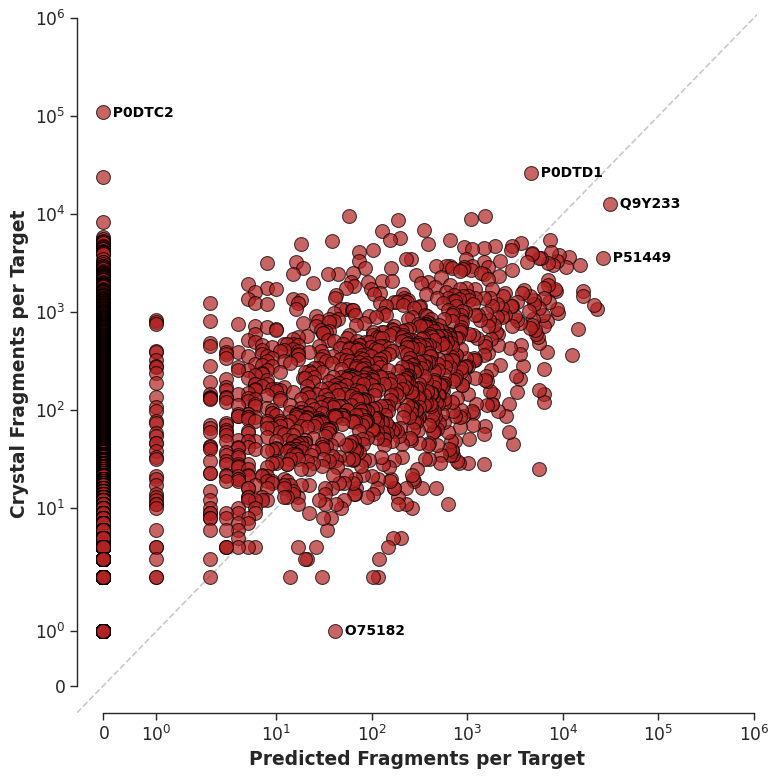

Plot saved as /home/joan/posal/deliverables/Notebooks/Images/scatter_plot_targets.png


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from rdkit import Chem
from tqdm import tqdm


PREDICTED_MAIN_FOLDER = f'{ZENODO_PATH}/SAFR_v1.0.1'
CRYSTAL_MAIN_FOLDER = f'{ZENODO_PATH}/Crystal_Fragments'
OUTPUT_DIR = f'{YOUR_PATH}/Images'

os.makedirs(OUTPUT_DIR, exist_ok=True)


def count_fragments_per_target(main_folder_path, col_name):
    """
    Iterates through subdirectories (Targets), counts valid molecules
    in all SDFs within, and returns a Pandas Series.
    """
    main_path = Path(main_folder_path)
    if not main_path.exists():
        print(f"Error: Path {main_path} does not exist.")
        return pd.Series(name=col_name)

    target_counts = {}


    subdirs = [d for d in main_path.iterdir() if d.is_dir()]

    print(f"\nScanning '{col_name}' targets in: {main_path}")
    for target_dir in tqdm(subdirs, desc=f"Counting {col_name}"):
        target_name = target_dir.name
        count = 0

        for sdf_file in target_dir.rglob('*.sdf'):
            try:
                suppl = Chem.SDMolSupplier(str(sdf_file), sanitize=False, removeHs=False)

                count += sum(1 for mol in suppl if mol is not None)
            except Exception:
                continue

        target_counts[target_name] = count

    return pd.Series(target_counts, name=col_name)


counts_pred = count_fragments_per_target(PREDICTED_MAIN_FOLDER, 'Predicted')
counts_cryst = count_fragments_per_target(CRYSTAL_MAIN_FOLDER, 'Crystal')

merged_counts = pd.concat([counts_pred, counts_cryst], axis=1).fillna(0)

csv_path = os.path.join(f"{YOUR_PATH}/Data", "Target_Fragment_Counts_Summary.csv")
merged_counts.index.name = 'Target_Name'
merged_counts.to_csv(csv_path)
print(f"\nSummary CSV saved to: {csv_path}")


merged_counts = merged_counts[merged_counts['Crystal'] > 0]

merged_counts['magnitude'] = np.sqrt(merged_counts['Predicted']**2 + merged_counts['Crystal']**2)
merged_counts = merged_counts.sort_values('magnitude', ascending=False)

labels_to_plot = set()

top_magnitude = merged_counts.sort_values('magnitude', ascending=False).head(4)
labels_to_plot.update(top_magnitude.index.tolist())


manual_target = "P51449"
if manual_target in merged_counts.index:
    labels_to_plot.add(manual_target)


subset_p0 = merged_counts[merged_counts['Predicted'] == 0]
if not subset_p0.empty:
    labels_to_plot.add(subset_p0['Crystal'].idxmax())


subset_c1 = merged_counts[merged_counts['Crystal'] == 1]
if not subset_c1.empty:
    labels_to_plot.add(subset_c1['Predicted'].idxmax())



print("\nGenerating scatter plot...")
sns.set_context("paper", font_scale=1.4)
sns.set_style("ticks")

plt.figure(figsize=(8, 8))


sns.scatterplot(
    data=merged_counts,
    x='Predicted',
    y='Crystal',
    color='firebrick',
    s=100,
    alpha=0.7,
    edgecolor='black',
    linewidth=0.8
)

plt.xscale('symlog')
plt.yscale('symlog')


max_val = max(merged_counts['Predicted'].max(), merged_counts['Crystal'].max())
limit_max = max_val * 10
limit_min = -0.5

plt.xlim(limit_min, limit_max)
plt.ylim(limit_min, limit_max)


plt.plot([limit_min, limit_max], [limit_min, limit_max],
         ls="--", c=".3", alpha=0.3, zorder=0)

for ac_name in labels_to_plot:
    if ac_name not in merged_counts.index: continue

    x_pos = merged_counts.loc[ac_name, 'Predicted']
    y_pos = merged_counts.loc[ac_name, 'Crystal']

    plt.text(
        x_pos,
        y_pos,
        f'  {ac_name}',
        fontsize=10,
        color='black',
        verticalalignment='center',
        fontweight='bold'
    )


plt.xlabel('Predicted Fragments per Target', fontweight='bold')
plt.ylabel('Crystal Fragments per Target', fontweight='bold')

sns.despine(trim=True)
plt.tight_layout()

plot_path = os.path.join(OUTPUT_DIR, 'scatter_plot_targets.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Plot saved as {plot_path}")

# Target Broad Family analysis for "Novel" Fragment-Uniprot Pairs


Extracting SAFR pairs from 6828 files across 5 CPUs...


Processing SAFR: 100%|██████████| 6828/6828 [00:07<00:00, 920.98it/s] 



Extracting Crystal pairs from 109571 files across 5 CPUs...


Processing Crystal: 100%|██████████| 109571/109571 [00:26<00:00, 4074.62it/s]



Total unique SAFR pairs: 231901
Total unique Crystal pairs: 353634
--> Found 198168 NOVEL target-fragment pairs in SAFR!

Loading family mapping from JSON...
Novel pairs saved to: /home/joan/posal/deliverables/Notebooks/Images/novel_target_fragment_pairs.csv

Generating bar plot...

Family Distribution:
family
kinase                  83904
other / unlabeled       45947
peptidase / protease    18937
reductase               15189
nuclear receptor        10593
GPCR                     8665
transcription factor     3820
enzyme (general)         3793
ion channel              2904
phosphatase              2497
transporter              1919
Name: count, dtype: int64


/tmp/ipykernel_3409857/1824019239.py:160: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Family', y='Count', data=counts_df, palette='inferno_r')


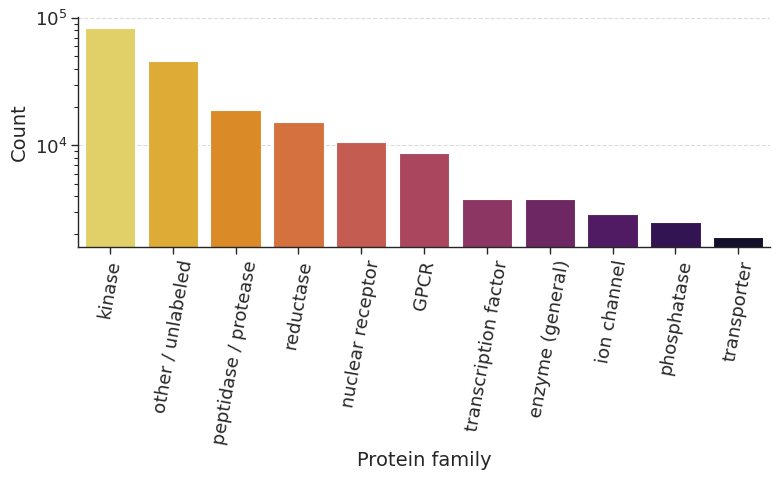

Plot saved successfully to: /home/joan/posal/deliverables/Notebooks/Images/family_value_counts_barplot.png


In [ ]:
import os
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from rdkit import Chem
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed

# --- CONFIGURATION ---

SAFR_MAIN_FOLDER = f'{ZENODO_PATH}/SAFR_v1.0.1'
CRYSTAL_MAIN_FOLDER = f'{ZENODO_PATH}/Crystal_Fragments'
JSON_MAPPING_PATH = f'{YOUR_PATH}/Data/ac_to_family_mapping.json'
OUTPUT_PLOT_DIR = f'{YOUR_PATH}/Images'

NUM_CPUS = 5
os.makedirs(OUTPUT_PLOT_DIR, exist_ok=True)

# --- MOLECULE PREPARATION ---
def defragment(mol, polarR: bool = False):
    """Removes dummy atoms (atomic number 0) and returns a cleaned RDKit Mol object."""
    fragment = Chem.Mol(mol)
    for atom in fragment.GetAtoms():
        if atom.GetAtomicNum() == 0:
            if polarR:
                neighbors = atom.GetNeighbors()
                if neighbors and neighbors[0].GetSymbol() != "C":
                    atom.SetAtomMapNum(0)
                    atom.SetIsotope(0)
                    continue
            atom.SetAtomicNum(1)
            atom.SetIsotope(0)
    try:
        fragment = Chem.RemoveAllHs(fragment, sanitize=True)
        Chem.SanitizeMol(fragment)
        return fragment
    except Exception:
        return None

# --- MULTIPROCESSING WORKERS ---
def process_sdf_for_pairs(file_path, target_ac):
    """
    Worker function: reads an SDF and returns a set of (Target_AC, InChIKey) tuples.
    """
    pairs = set()
    try:
        suppl = Chem.SDMolSupplier(str(file_path), sanitize=False, removeHs=False)
        for raw_mol in suppl:
            if raw_mol is None: continue

            try:

                if raw_mol.HasProp("InchiKey"):
                    inchikey = raw_mol.GetProp("InchiKey")
                else:

                    mol = defragment(raw_mol)
                    if mol is None: continue
                    inchikey = Chem.MolToInchiKey(mol)

                if inchikey:
                    pairs.add((target_ac, inchikey))
            except Exception:
                continue
    except Exception:
        pass

    return pairs

def extract_all_target_fragment_pairs(main_folder, label, num_workers):
    """
    Discovers all SDFs in target subfolders and uses multiprocessing to extract pairs.
    """
    main_path = Path(main_folder)
    if not main_path.exists():
        print(f"Error: Path {main_path} does not exist.")
        return set()

    tasks = []
    subdirs = [d for d in main_path.iterdir() if d.is_dir()]

    for target_dir in subdirs:
        target_ac = target_dir.name
        for sdf_file in target_dir.rglob('*.sdf'):
            tasks.append((sdf_file, target_ac))

    all_pairs = set()
    print(f"\nExtracting {label} pairs from {len(tasks)} files across {num_workers} CPUs...")

    with ProcessPoolExecutor(max_workers=num_workers) as executor:
        future_to_task = {executor.submit(process_sdf_for_pairs, f, ac): ac for f, ac in tasks}

        for future in tqdm(as_completed(future_to_task), total=len(tasks), desc=f"Processing {label}"):
            try:
                result_set = future.result()
                all_pairs.update(result_set)
            except Exception as e:
                continue

    return all_pairs


# --- EXECUTION ---
if __name__ == '__main__':

    safr_pairs = extract_all_target_fragment_pairs(SAFR_MAIN_FOLDER, "SAFR", NUM_CPUS)
    crystal_pairs = extract_all_target_fragment_pairs(CRYSTAL_MAIN_FOLDER, "Crystal", NUM_CPUS)

    print(f"\nTotal unique SAFR pairs: {len(safr_pairs)}")
    print(f"Total unique Crystal pairs: {len(crystal_pairs)}")


    novel_pairs = safr_pairs - crystal_pairs
    print(f"--> Found {len(novel_pairs)} NOVEL target-fragment pairs in SAFR!")

    if len(novel_pairs) == 0:
        print("No novel pairs found. Exiting.")
        exit()


    df = pd.DataFrame(list(novel_pairs), columns=['ac', 'inchikey'])

    print("\nLoading family mapping from JSON...")
    try:
        with open(JSON_MAPPING_PATH, 'r') as f:
            mapping_dict = json.load(f)


        df['family'] = df['ac'].map(mapping_dict)
    except FileNotFoundError:
        print(f"Warning: {JSON_MAPPING_PATH} not found. All families will be marked as unlabeled.")
        df['family'] = np.nan


    csv_out = os.path.join(f"{YOUR_PATH}/Data", "novel_target_fragment_pairs.csv")
    df.to_csv(csv_out, index=False)
    print(f"Novel pairs saved to: {csv_out}")


    # ---  PLOTTING ---
    print("\nGenerating bar plot...")

    counts_series = df['family'].replace([np.nan, 'None'], 'other / unlabeled').value_counts()

    print("\nFamily Distribution:")
    print(counts_series)


    counts_df = counts_series.reset_index()
    counts_df.columns = ['Family', 'Count']
    counts_df = counts_df.sort_values(by='Count', ascending=False)


    plt.figure(figsize=(8, 5))


    plt.yscale('log')
    sns.barplot(x='Family', y='Count', data=counts_df, palette='inferno_r')
    sns.despine()


    plt.title('', fontsize=14)
    plt.xlabel('Protein family', fontsize=14)
    plt.ylabel('Count', fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=80, fontsize=13)
    plt.yticks(fontsize=13)
    plt.tight_layout()

    save_path = os.path.join(OUTPUT_PLOT_DIR, "family_value_counts_barplot.png")
    plt.savefig(save_path, dpi=500)
    plt.show()


# Per Broad "family" scaffold analysis


Processing 1142 scaffold files across 5 CPUs...


Reading Scaffolds: 100%|██████████| 1142/1142 [01:07<00:00, 17.00it/s]



Total scaffolds extracted: 818385
Loading family mapping from JSON...
Aggregating counts by scaffold and family...

Generating Scatter Plot...


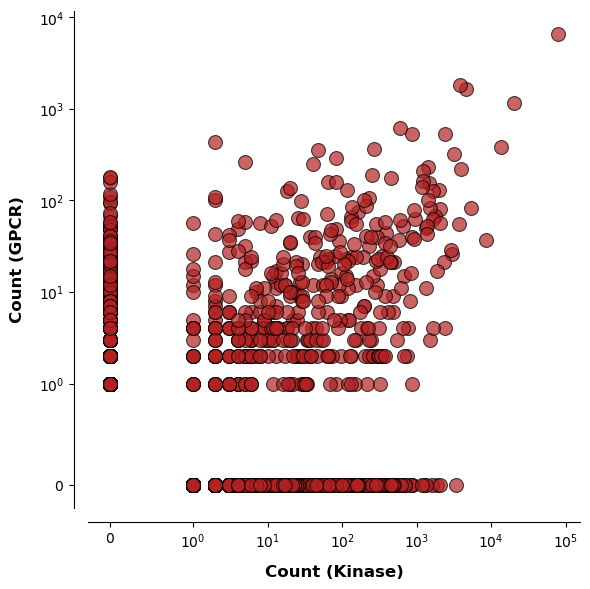

Plot saved successfully to: /home/joan/posal/deliverables/Notebooks/Images/kinase_gpcr_symlog.png


In [ ]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from rdkit import Chem
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed

# --- CONFIGURATION ---
SCAFFOLDS_FOLDER = '/home/joan/posal/deliverables/SAFR_Scaffolds'
JSON_MAPPING_PATH = f'{YOUR_PATH}/Data/ac_to_family_mapping.json'
OUTPUT_DIR = f'{YOUR_PATH}/Images'
NUM_CPUS = 5

os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- MOLECULE PREPARATION ---
def defragment(mol, polarR: bool = False):
    """Removes dummy atoms to ensure a clean InChIKey calculation."""
    fragment = Chem.Mol(mol)
    for atom in fragment.GetAtoms():
        if atom.GetAtomicNum() == 0:
            if polarR:
                neighbors = atom.GetNeighbors()
                if neighbors and neighbors[0].GetSymbol() != "C":
                    atom.SetAtomMapNum(0)
                    atom.SetIsotope(0)
                    continue
            atom.SetAtomicNum(1)
            atom.SetIsotope(0)
    try:
        fragment = Chem.RemoveAllHs(fragment, sanitize=True)
        Chem.SanitizeMol(fragment)
        return fragment
    except Exception:
        return None

# --- MULTIPROCESSING WORKER ---
def process_scaffold_sdf(file_path):
    """
    Worker function: Extracts the AC from the filename, calculates the
    InChIKey for each scaffold, and returns a list of dictionaries.
    """
    ac = file_path.stem
    records = []

    try:
        suppl = Chem.SDMolSupplier(str(file_path), sanitize=False, removeHs=False)
        for raw_mol in suppl:
            if raw_mol is None: continue

            try:

                mol = defragment(raw_mol)
                if mol is None: continue
                smiles = Chem.MolToSmiles(mol)


                inchikey = Chem.MolToInchiKey(mol)

                if inchikey:
                    records.append({'ac': ac, 'scaffold_key': inchikey, 'smiles': smiles})
            except Exception:
                continue
    except Exception:
        pass

    return records

# --- EXECUTION ---
if __name__ == '__main__':


    folder_path = Path(SCAFFOLDS_FOLDER)
    sdf_files = list(folder_path.glob('*.sdf'))

    if not sdf_files:
        print(f"Error: No SDF files found in {folder_path}")
        exit()

    print(f"\nProcessing {len(sdf_files)} scaffold files across {NUM_CPUS} CPUs...")

    all_records = []
    with ProcessPoolExecutor(max_workers=NUM_CPUS) as executor:
        future_to_file = {executor.submit(process_scaffold_sdf, f): f for f in sdf_files}

        for future in tqdm(as_completed(future_to_file), total=len(sdf_files), desc="Reading Scaffolds"):
            records = future.result()
            all_records.extend(records)

    df = pd.DataFrame(all_records)
    print(f"\nTotal scaffolds extracted: {len(df)}")

    print("Loading family mapping from JSON...")
    try:
        with open(JSON_MAPPING_PATH, 'r') as f:
            mapping_dict = json.load(f)


        df['family'] = df['ac'].map(mapping_dict)

        df['family'] = df['family'].fillna('Unknown')
    except FileNotFoundError:
        print(f"Warning: {JSON_MAPPING_PATH} not found. Ensure the file is in the directory.")
        exit()


    print("Aggregating counts by scaffold and family...")
    counts = df.groupby(['scaffold_key', 'smiles', 'family']).size().unstack(fill_value=0)


    if 'kinase' not in counts.columns: counts['kinase'] = 0
    if 'GPCR' not in counts.columns: counts['GPCR'] = 0

    plot_data = counts[['kinase', 'GPCR']].copy()
    plot_data = plot_data[(plot_data['kinase'] > 0) | (plot_data['GPCR'] > 0)]

    # --- PLOTTING ---
    print("\nGenerating Scatter Plot...")
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.scatter(plot_data['kinase'], plot_data['GPCR'],
               c='firebrick',
               s=100,
               alpha=0.7,
               edgecolor='black',
               linewidth=0.8
            )


    ax.set_xscale('symlog', linthresh=1)
    ax.set_yscale('symlog', linthresh=1)

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)


    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))


    ax.set_xlabel('Count (Kinase)', fontsize=12, labelpad=10, fontweight='bold')
    ax.set_ylabel('Count (GPCR)', fontsize=12, labelpad=10, fontweight='bold')


    plt.tight_layout()

    save_path = os.path.join(OUTPUT_DIR, 'kinase_gpcr_symlog.png')
    plt.savefig(save_path, dpi=500)
    plt.show()

    print(f"Plot saved successfully to: {save_path}")

In [ ]:
import os
import pandas as pd
from rdkit.Chem import Draw
from rdkit import Chem

OUTPUT_DIR = f"{YOUR_PATH}/Images/Scaffolds_per_family"
os.makedirs(OUTPUT_DIR, exist_ok=True)


print("Aggregating counts by scaffold and family for ALL families...")
all_counts = df.groupby(['scaffold_key', 'smiles', 'family']).size().unstack(fill_value=0)


all_counts_reset = all_counts.reset_index()


family_cols = [col for col in all_counts_reset.columns if col not in ['scaffold_key', 'smiles']]

for target_family in family_cols:
    print(f"\nDrawing 3x3 grid for top 9 exclusive '{target_family}' Scaffolds...")

    other_families = [col for col in family_cols if col != target_family]
    if other_families:
        exclusive_scaffolds = all_counts_reset[
            (all_counts_reset[target_family] > 0) &
            (all_counts_reset[other_families].sum(axis=1) == 0)
        ].sort_values(by=target_family, ascending=False).head(9)
    else:
        exclusive_scaffolds = all_counts_reset[
            all_counts_reset[target_family] > 0
        ].sort_values(by=target_family, ascending=False).head(9)

    if exclusive_scaffolds.empty:
        print(f"No exclusive scaffolds found for {target_family}.")
        continue

    mols = [Chem.MolFromSmiles(smiles) for smiles in exclusive_scaffolds['smiles']]


    legends = [f"N: {int(count)}" for count in exclusive_scaffolds[target_family]]

    dopts = Draw.rdMolDraw2D.MolDrawOptions()
    dopts.useBWAtomPalette()
    dopts.setBackgroundColour((1, 1, 1))
    dopts.bondLineWidth = 5.0
    dopts.minFontSize = 30
    dopts.fixedBondLength = 40
    dopts.additionalAtomLabelPadding = 0.1
    dopts.addStereoAnnotation = True
    dopts.legendFontSize = 45
    dopts.legendFraction = 0.3

    grid_img = Draw.MolsToGridImage(
            mols,
            molsPerRow=3,
            subImgSize=(400, 400),
            legends=legends,
            drawOptions=dopts,
            returnPNG=False
    )

    safe_family_name = str(target_family).replace(" ", "_").replace("/", "-")
    grid_save_path = os.path.join(OUTPUT_DIR, f"{safe_family_name}_Exclusive_Top9_Scaffolds_Grid.png")
    grid_img.save(grid_save_path)
    print(f"Molecule grid saved successfully to: {grid_save_path}")

Aggregating counts by scaffold and family for ALL families...

Drawing 3x3 grid for top 9 exclusive 'GPCR' Scaffolds...
Molecule grid saved successfully to: /home/joan/posal/deliverables/Notebooks/Images/Scaffolds_per_family/GPCR_Exclusive_Top9_Scaffolds_Grid.png

Drawing 3x3 grid for top 9 exclusive 'None' Scaffolds...
Molecule grid saved successfully to: /home/joan/posal/deliverables/Notebooks/Images/Scaffolds_per_family/None_Exclusive_Top9_Scaffolds_Grid.png

Drawing 3x3 grid for top 9 exclusive 'Unknown' Scaffolds...
Molecule grid saved successfully to: /home/joan/posal/deliverables/Notebooks/Images/Scaffolds_per_family/Unknown_Exclusive_Top9_Scaffolds_Grid.png

Drawing 3x3 grid for top 9 exclusive 'enzyme (general)' Scaffolds...
Molecule grid saved successfully to: /home/joan/posal/deliverables/Notebooks/Images/Scaffolds_per_family/enzyme_(general)_Exclusive_Top9_Scaffolds_Grid.png

Drawing 3x3 grid for top 9 exclusive 'ion channel' Scaffolds...
Molecule grid saved successfully to

# Distribution of ligands per template 

In [ ]:
import pandas as pd
df = pd.read_csv(f"{YOUR_PATH}/Data/Template_reusability.csv")

display(df)

,BindingDB_Compound_id,InchiKey,chembl_id,confidence_score,exp_activity,ligand,ligand_inchikey,pdb,uniprot,template
0,BDBM589282,OXBOMHSVCGUIRM-UHFFFAOYSA-N,CHEMBL5925540,0.672964,6.4,1090775,BXDCBKZTQVWUPA-UHFFFAOYSA-N,6o0h,P53396,380075
1,BDBM50328602,VWFNTPCDOKRSPO-UHFFFAOYSA-N,NaN,0.604185,7.2,1088542,MLRYKMPLYNACRR-UHFFFAOYSA-P,4jsx,P42345,231968
2,BDBM535436,NNJMHJRBXQSTCT-YFKPBYRVSA-N,NaN,0.625091,8.3,1090759,YHCHSJVYIURCJK-BVRKHOPBSA-N,7bit,Q00987,191925
3,BDBM359592,SAKPFMLCHMCEEL-UHFFFAOYSA-N,NaN,0.605003,7.9,1090615,XPHYMDIHBLQAFW-UHFFFAOYSA-M,5c4s,P51449,206997
4,BDBM218246,OOSJPOUYHNXOML-UHFFFAOYSA-N,NaN,0.617208,7.5,1086696,TUXHICXXXYWUPK-UHFFFAOYSA-O,8q61,P31751,96759
...,...,...,...,...,...,...,...,...,...,...
818236,BDBM108915,DZKOKDAFGONQEE-UHFFFAOYSA-N,CHEMBL3675079,0.609656,8.5,1628336,BBEQCWUMTXOSEY-UHFFFAOYSA-N,4jkt,D3Z7P3,55290
818237,BDBM365842,SHHRDAGTJAEWNC-VIFPVBQESA-N,CHEMBL5855836,0.644810,6.3,1627557,RUUNMWXKBFSZIJ-IBGZPJMESA-N,6nm8,Q9NZQ7,245422
818238,BDBM109080,UHOVQNZJYSORNB-UHFFFAOYSA-N,CHEMBL3679997,0.636061,8.3,1627974,BAGOJANZLGJDHR-UHFFFAOYSA-N,4jkt,D3Z7P3,55290
818239,BDBM349206,LODWETPPHNUHOT-UHFFFAOYSA-N,CHEMBL5921684,0.619211,6.5,1627919,KKUPHKTWQQTGHJ-UHFFFAOYSA-N,5ut5,O60674,289883


--- Template Reuse Statistics ---
Total Unique Templates: 8,806
Mean Reuse: 7.91 unique ligands per template
Median Reuse: 3.0 unique ligands per template
Max Reuse: 631 unique ligands (Template: 515767)

✅ Plot saved successfully as '/home/joan/posal/deliverables/Notebooks/Images/template_reuse_continuous_unique.png'


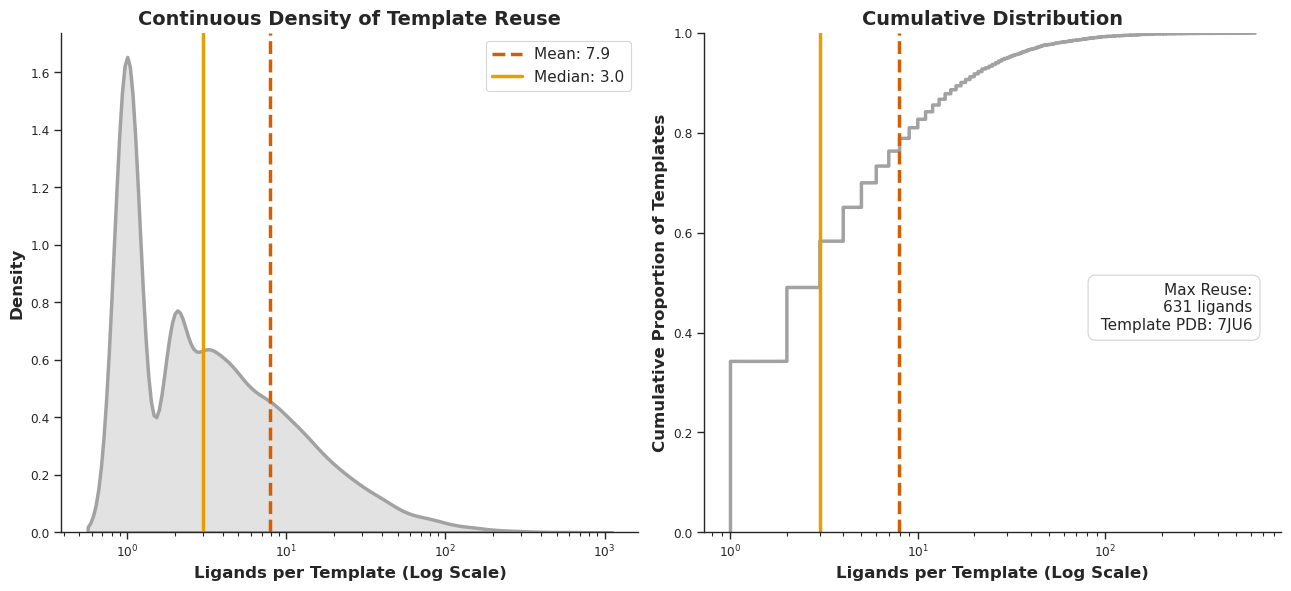

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_template_reuse_continuous(df):

    unique_pairs = df.drop_duplicates(subset=['template', 'ligand'])
    template_counts = unique_pairs['template'].value_counts()


    mean_reuse = template_counts.mean()
    median_reuse = template_counts.median()
    max_reuse = template_counts.max()
    most_used_pdb = template_counts.idxmax()
    total_templates = len(template_counts)

    print(f"--- Template Reuse Statistics ---")
    print(f"Total Unique Templates: {total_templates:,}")
    print(f"Mean Reuse: {mean_reuse:.2f} unique ligands per template")
    print(f"Median Reuse: {median_reuse:.1f} unique ligands per template")
    print(f"Max Reuse: {max_reuse} unique ligands (Template: {most_used_pdb})")


    sns.set_theme(style="ticks", context="paper")
    fig, axes = plt.subplots(1, 2, figsize=(13, 6))


    color_data = "#A2A2A2"
    color_mean = '#D55E00'
    color_median = '#E69F00'


    ax1 = axes[0]

    sns.kdeplot(template_counts, log_scale=True, fill=True, color=color_data,
                alpha=0.3, linewidth=2.5, bw_adjust=1, ax=ax1)

    ax1.axvline(x=mean_reuse, color=color_mean, linestyle='--', lw=2.5, label=f'Mean: {mean_reuse:.1f}')
    ax1.axvline(x=median_reuse, color=color_median, linestyle='-', lw=2.5, label=f'Median: {median_reuse:.1f}')


    ax1.set_title('Continuous Density of Template Reuse', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Ligands per Template (Log Scale)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Density', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=11)


    ax2 = axes[1]

    sns.ecdfplot(template_counts, log_scale=True, color=color_data, linewidth=2.5, ax=ax2)

    ax2.axvline(x=mean_reuse, color=color_mean, linestyle='--', lw=2.5)
    ax2.axvline(x=median_reuse, color=color_median, linestyle='-', lw=2.5)


    ax2.text(0.95, 0.45, f'Max Reuse:\n{max_reuse} ligands\n Template PDB: 7JU6',
            transform=ax2.transAxes, ha='right', va='center', fontsize=11,
            bbox=dict(facecolor='white', edgecolor='lightgray', boxstyle='round,pad=0.5'))

    ax2.set_title('Cumulative Distribution', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Ligands per Template (Log Scale)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Cumulative Proportion of Templates', fontsize=12, fontweight='bold')


    sns.despine()
    plt.tight_layout()


    output_filename = f'{YOUR_PATH}/Images/template_reuse_continuous_unique.png'
    plt.savefig(output_filename, dpi=500)
if __name__ == "__main__":

    plot_template_reuse_continuous(df)